## Stage 1: Preprocessing, EDA and Feature Engineering

### Data Cleaning and Exploratory Data Analysis

Import needed libraries and setup plotting parameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
import os
import kagglehub

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**1. Load and explore dataset**

In [2]:
print("=" * 80)
print("LOADING DATASET")
print("=" * 80)

# Download and load dataset
path = kagglehub.dataset_download("joniarroba/noshowappointments")
print(f"✓ Dataset path: {path}")

csv_file = os.path.join(path, 'KaggleV2-May-2016.csv')
df = pd.read_csv(csv_file)

print(f"\n1.1 Dataset Shape:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n1.2 First Few Rows:")
print(df.head())

print("\n1.3 Column Names and Data Types:")
print(df.dtypes)

print("\n1.4 Basic Information:")
print(df.info())

print("\n1.5 Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("✓ No missing values found")

print("\n1.6 Duplicate Rows:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates:,}")


LOADING DATASET
100%|██████████| 2.40M/2.40M [00:00<00:00, 105MB/s]Extracting files...
✓ Dataset path: /root/.cache/kagglehub/datasets/joniarroba/noshowappointments/versions/5


1.1 Dataset Shape:
Rows: 110,527
Columns: 14

1.2 First Few Rows:
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0     

**2. Data cleaning and preprocessing**

In [3]:
print("\n" + "=" * 80)
print("DATA CLEANING AND PREPROCESSING")
print("=" * 80)

# 2.1 Fix column names (remove typos)
print("\n2.1 Renaming columns with typos...")
df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'SMS_received': 'SMS_Received',
    'No-show': 'No_Show'
}, inplace=True)
print("✓ Columns renamed")

# 2.2 Convert date columns to datetime
print("\n2.2 Converting date columns to datetime...")
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
print("✓ Date columns converted")

# 2.3 Handle Age anomalies
print("\n2.3 Investigating Age distribution...")
print(f"Age statistics:")
print(df['Age'].describe())
print(f"\nMinimum age: {df['Age'].min()}")
print(f"Maximum age: {df['Age'].max()}")

# Check for negative or extremely high ages
negative_age = (df['Age'] < 0).sum()
very_high_age = (df['Age'] > 100).sum()
print(f"\nNegative ages: {negative_age}")
print(f"Ages > 100: {very_high_age}")

# Handle negative ages (set to 0 or drop - we'll set to absolute value)
if negative_age > 0:
    print(f"→ Converting {negative_age} negative ages to absolute values")
    df['Age'] = df['Age'].abs()

# Optionally cap extremely high ages (we can adjust this threshold)
if very_high_age > 0:
    print(f"→ Keeping ages > 100 as is (could be valid, though rare)")
    # Alternative: df.loc[df['Age'] > 115, 'Age'] = 115  # Cap at 115

# 2.4 Check Handicap values (should be 0-4 scale)
print("\n2.4 Investigating Handicap values...")
print(f"Handicap value counts:")
print(df['Handicap'].value_counts().sort_index())

# Any values outside 0-4 should be capped
if df['Handicap'].max() > 4:
    print(f"→ Capping Handicap values > 4")
    df['Handicap'] = df['Handicap'].clip(upper=4)

# 2.5 Convert No_Show to binary (currently 'Yes'/'No' strings)
print("\n2.5 Converting No_Show to binary...")
print(f"Original values: {df['No_Show'].unique()}")
# 'Yes' means patient did NOT show up (confusing, but that's the dataset)
df['No_Show_Binary'] = (df['No_Show'] == 'Yes').astype(int)
print("✓ Created No_Show_Binary: 1 = No-show, 0 = Showed up")

# 2.6 Calculate Lead Time (days between scheduling and appointment)
print("\n2.6 Calculating lead time...")
df['Lead_Time_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
print("✓ Lead_Time_Days calculated")

# Check for negative lead times (appointments scheduled after appointment date - data error)
negative_lead = (df['Lead_Time_Days'] < 0).sum()
print(f"Negative lead times: {negative_lead}")
if negative_lead > 0:
    print(f"→ Removing {negative_lead} rows with negative lead times (data errors)")
    df = df[df['Lead_Time_Days'] >= 0]

# 2.7 Extract temporal features
print("\n2.7 Extracting temporal features...")
df['Appointment_DayOfWeek'] = df['AppointmentDay'].dt.day_name()
df['Appointment_Month'] = df['AppointmentDay'].dt.month_name()
df['Appointment_Hour'] = df['ScheduledDay'].dt.hour
df['Is_Weekend'] = df['AppointmentDay'].dt.dayofweek.isin([5, 6]).astype(int)
print("✓ Temporal features extracted")

print("\n2.8 Final dataset shape after cleaning:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


DATA CLEANING AND PREPROCESSING

2.1 Renaming columns with typos...
✓ Columns renamed

2.2 Converting date columns to datetime...
✓ Date columns converted

2.3 Investigating Age distribution...
Age statistics:
count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

Minimum age: -1
Maximum age: 115

Negative ages: 1
Ages > 100: 7
→ Converting 1 negative ages to absolute values
→ Keeping ages > 100 as is (could be valid, though rare)

2.4 Investigating Handicap values...
Handicap value counts:
Handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

2.5 Converting No_Show to binary...
Original values: ['No' 'Yes']
✓ Created No_Show_Binary: 1 = No-show, 0 = Showed up

2.6 Calculating lead time...
✓ Lead_Time_Days calculated
Negative lead times: 38568
→ Removing 38568 rows with negative lead times 

**3. Summary statistics**

In [4]:
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# 3.1 Overall no-show rate
no_show_rate = df['No_Show_Binary'].mean() * 100
show_rate = 100 - no_show_rate
print(f"\n3.1 Overall No-Show Rate:")
print(f"No-shows: {no_show_rate:.2f}%")
print(f"Showed up: {show_rate:.2f}%")
print(f"Total appointments: {len(df):,}")

# 3.2 Demographic statistics
print(f"\n3.2 Demographics:")
print(f"Gender distribution:")
print(df['Gender'].value_counts())
print(f"\nAge statistics:")
print(df['Age'].describe())

# 3.3 Medical conditions
print(f"\n3.3 Medical Conditions:")
print(f"Hypertension: {df['Hypertension'].sum():,} ({df['Hypertension'].mean()*100:.1f}%)")
print(f"Diabetes: {df['Diabetes'].sum():,} ({df['Diabetes'].mean()*100:.1f}%)")
print(f"Alcoholism: {df['Alcoholism'].sum():,} ({df['Alcoholism'].mean()*100:.1f}%)")
print(f"Handicap (>0): {(df['Handicap'] > 0).sum():,} ({(df['Handicap'] > 0).mean()*100:.1f}%)")

# 3.4 SMS and Scholarship
print(f"\n3.4 SMS Reminders & Scholarship:")
print(f"SMS sent: {df['SMS_Received'].sum():,} ({df['SMS_Received'].mean()*100:.1f}%)")
print(f"Scholarship (welfare): {df['Scholarship'].sum():,} ({df['Scholarship'].mean()*100:.1f}%)")

# 3.5 Lead time statistics
print(f"\n3.5 Lead Time Statistics:")
print(df['Lead_Time_Days'].describe())

# 3.6 Appointments by day of week
print(f"\n3.6 Appointments by Day of Week:")
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(df['Appointment_DayOfWeek'].value_counts().reindex(day_order))

# 3.7 Unique neighborhoods
print(f"\n3.7 Location:")
print(f"Number of unique neighborhoods: {df['Neighbourhood'].nunique()}")
print(f"Top 5 neighborhoods:")
print(df['Neighbourhood'].value_counts().head())


SUMMARY STATISTICS

3.1 Overall No-Show Rate:
No-shows: 28.52%
Showed up: 71.48%
Total appointments: 71,959

3.2 Demographics:
Gender distribution:
Gender
F    48070
M    23889
Name: count, dtype: int64

Age statistics:
count    71959.000000
mean        38.502564
std         22.925421
min          0.000000
25%         19.000000
50%         39.000000
75%         57.000000
max        115.000000
Name: Age, dtype: float64

3.3 Medical Conditions:
Hypertension: 15,032 (20.9%)
Diabetes: 5,377 (7.5%)
Alcoholism: 1,822 (2.5%)
Handicap (>0): 1,307 (1.8%)

3.4 SMS Reminders & Scholarship:
SMS sent: 35,482 (49.3%)
Scholarship (welfare): 6,671 (9.3%)

3.5 Lead Time Statistics:
count    71959.000000
mean        14.642018
std         16.494334
min          0.000000
25%          3.000000
50%          8.000000
75%         21.000000
max        178.000000
Name: Lead_Time_Days, dtype: float64

3.6 Appointments by Day of Week:
Appointment_DayOfWeek
Monday       14581.0
Tuesday      16462.0
Wednesday    1

**4. Visualisations**


GENERATING VISUALIZATIONS

4.1 Creating: No-show rate by day of week...
✓ Saved: figures/noshow_by_dayofweek.png


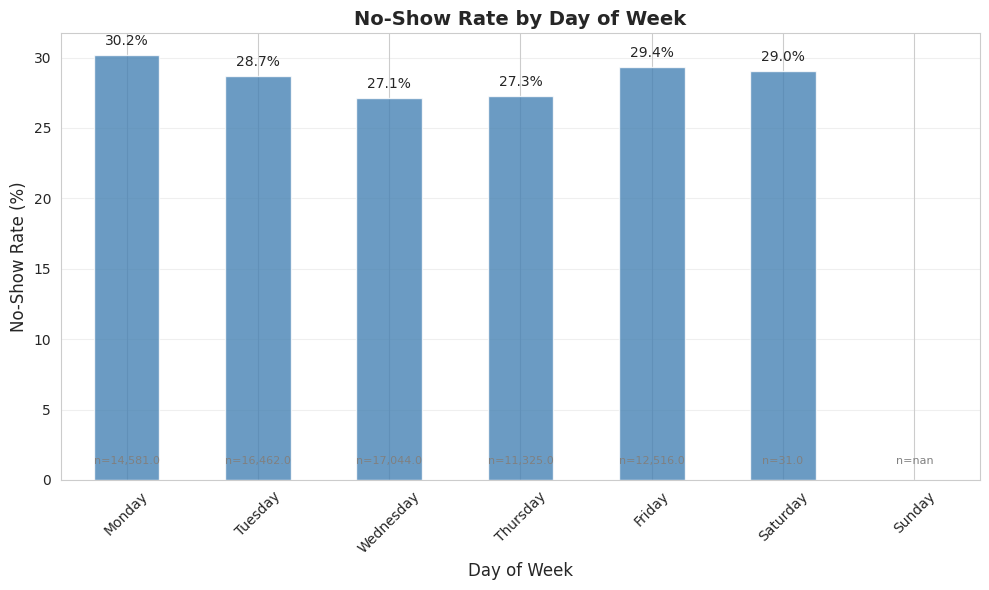


4.2 Creating: No-show rate by lead time...
✓ Saved: figures/noshow_by_leadtime.png


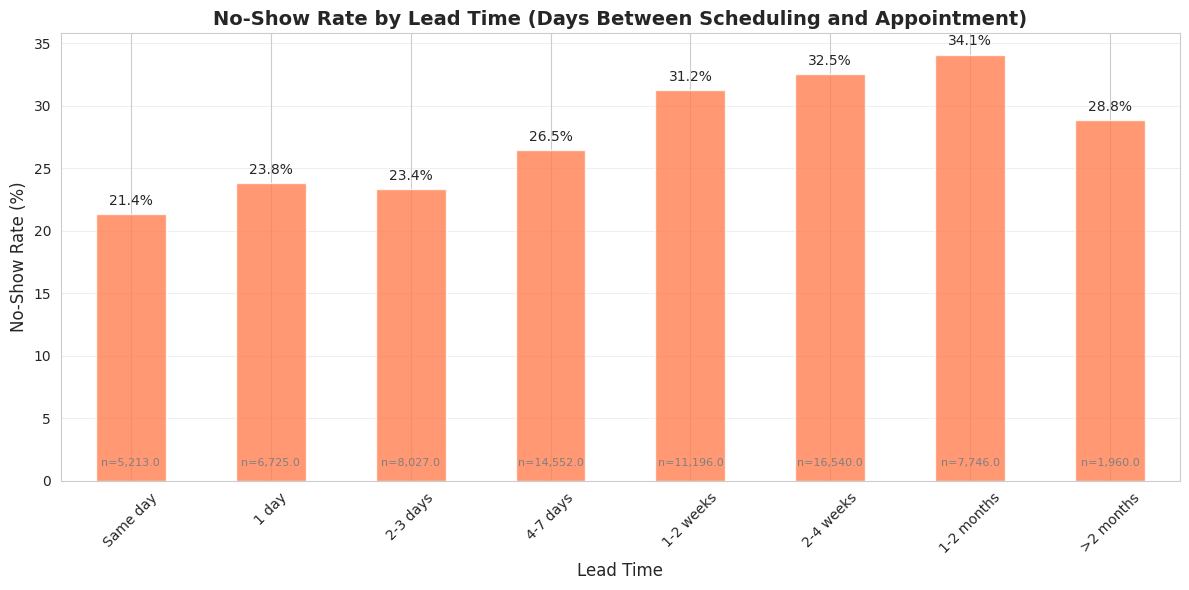


4.3 Creating: Lead time distribution (detailed)...
✓ Saved: figures/leadtime_detailed.png


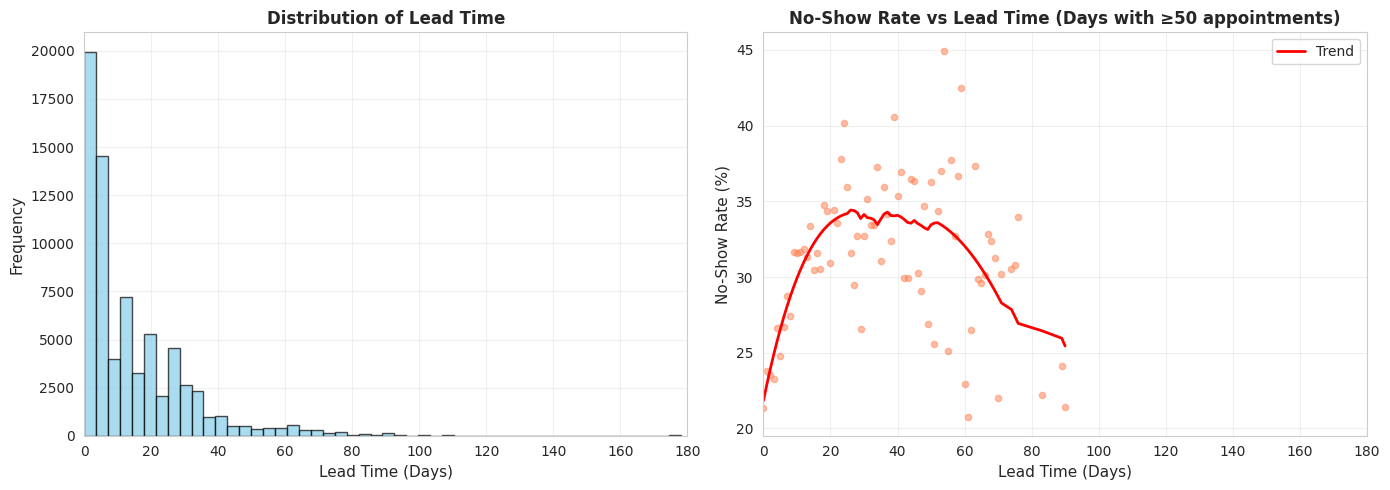


4.4 Creating: Feature distributions...
✓ Saved: figures/feature_distributions.png


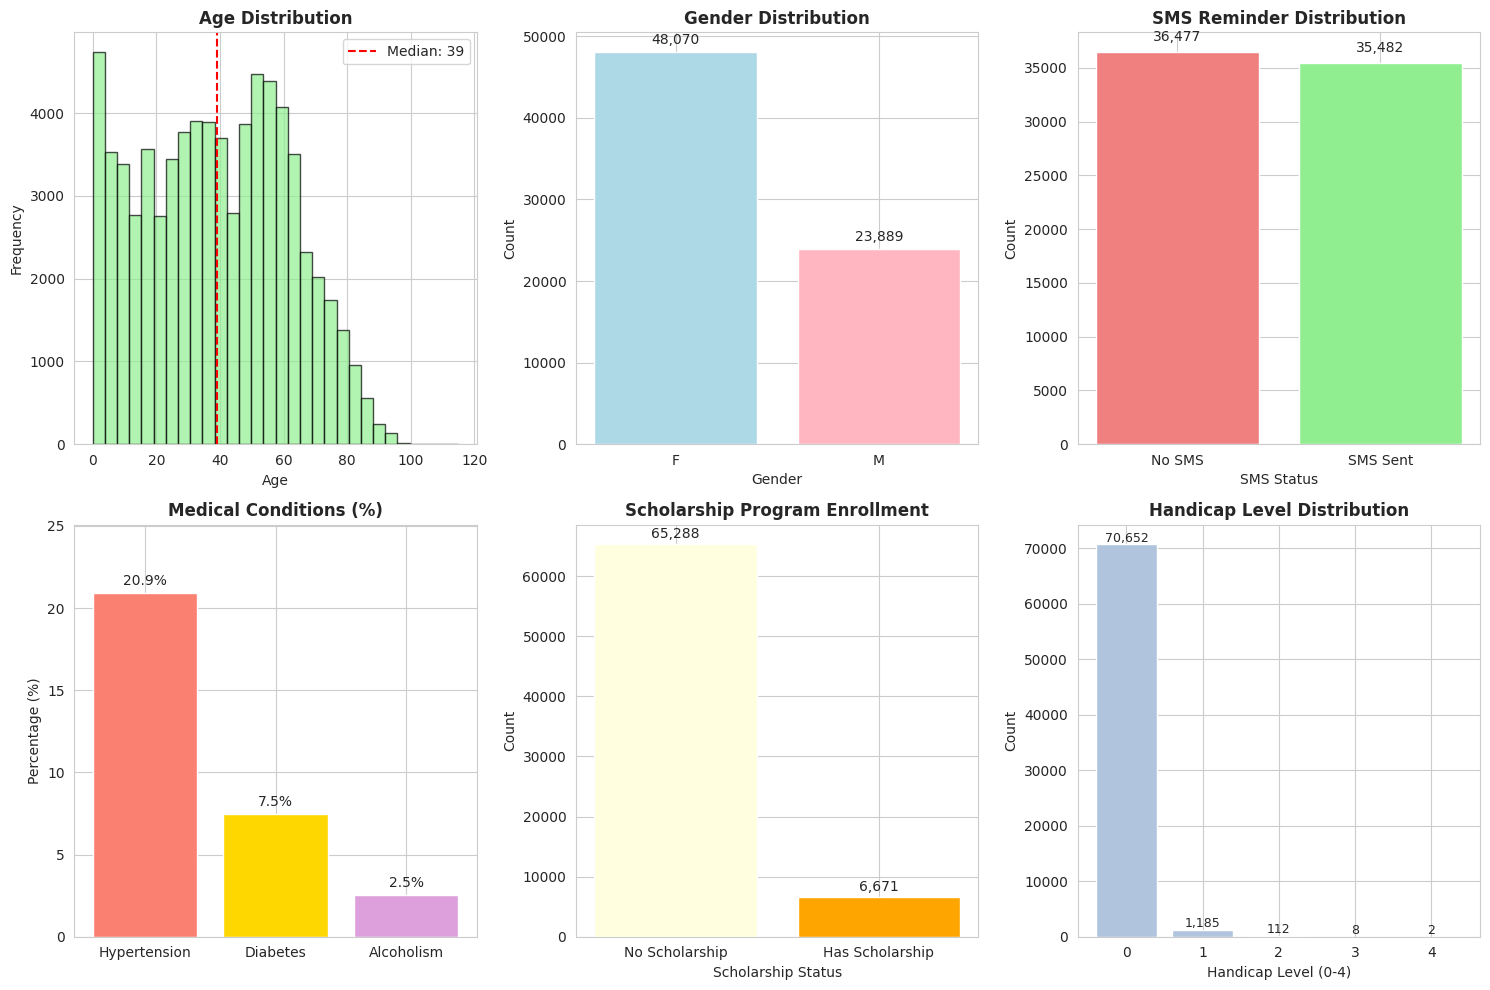


4.5 Creating: No-show rate comparisons...
✓ Saved: figures/noshow_comparisons.png


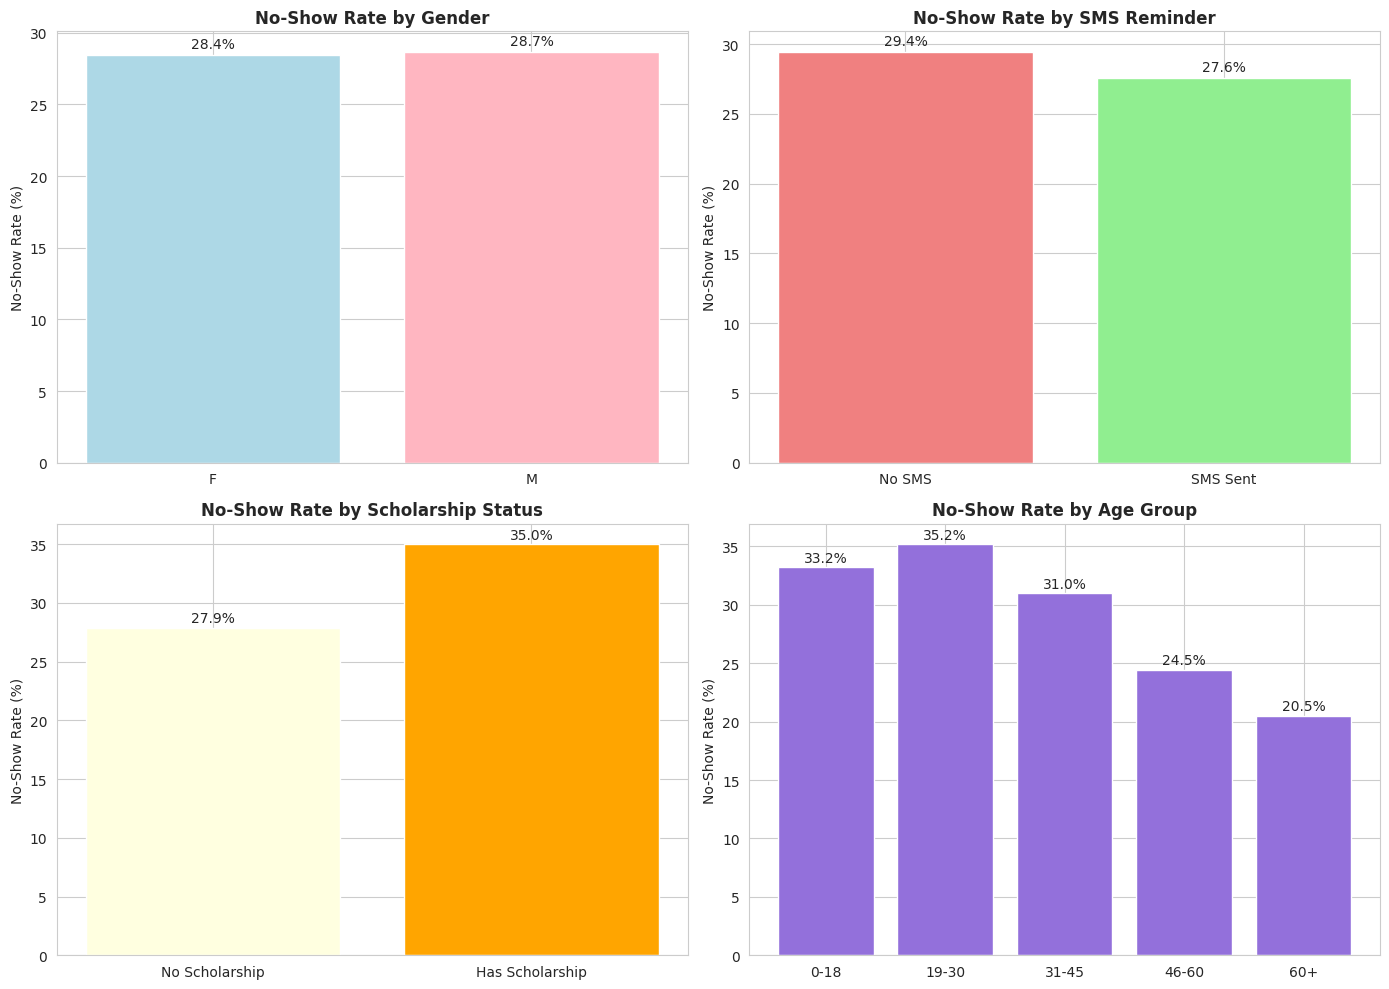


4.6 Creating: Correlation heatmap...
✓ Saved: figures/correlation_heatmap.png


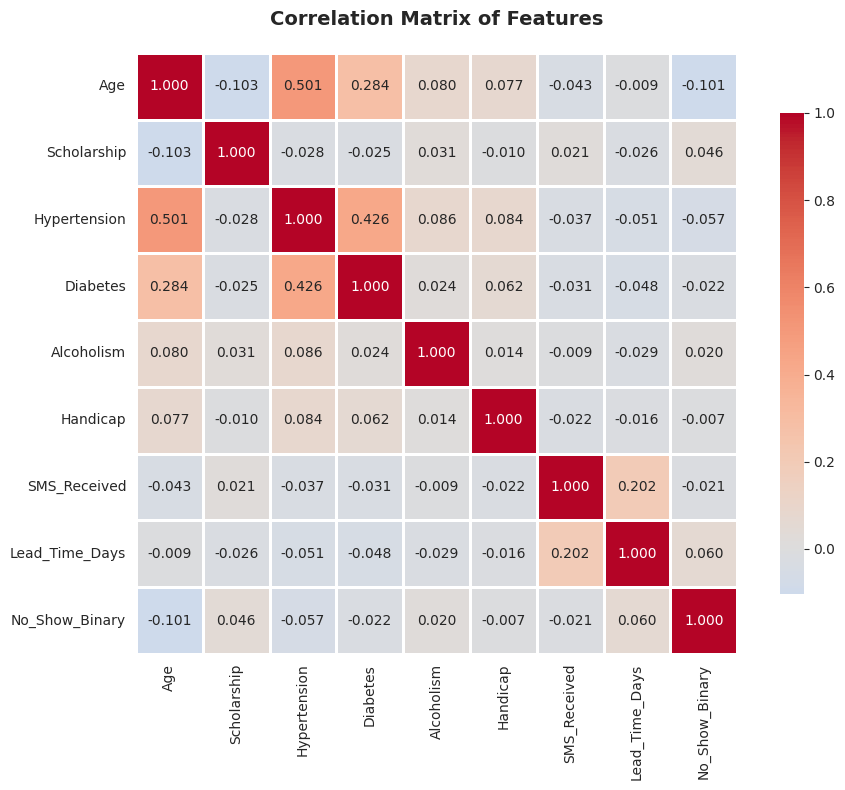

In [5]:
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

# Create a figure directory
import os
os.makedirs('figures', exist_ok=True)

# 4.1 No-show rate by day of week
print("\n4.1 Creating: No-show rate by day of week...")
plt.figure(figsize=(10, 6))

# Calculate no-show rate by day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
no_show_by_day = df.groupby('Appointment_DayOfWeek')['No_Show_Binary'].agg(['mean', 'count'])
no_show_by_day = no_show_by_day.reindex(day_order)
no_show_by_day['mean_pct'] = no_show_by_day['mean'] * 100

# Create bar plot
ax = no_show_by_day['mean_pct'].plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('No-Show Rate by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (day, row) in enumerate(no_show_by_day.iterrows()):
    ax.text(i, row['mean_pct'] + 0.5, f"{row['mean_pct']:.1f}%", 
            ha='center', va='bottom', fontsize=10)

# Add count labels
for i, (day, row) in enumerate(no_show_by_day.iterrows()):
    ax.text(i, 1, f"n={row['count']:,}", 
            ha='center', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('figures/noshow_by_dayofweek.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/noshow_by_dayofweek.png")
plt.show()
plt.close()

# 4.2 No-show rate by lead time
print("\n4.2 Creating: No-show rate by lead time...")

# Group lead time into bins for better visualization
df['Lead_Time_Bin'] = pd.cut(df['Lead_Time_Days'], 
                              bins=[-1, 0, 1, 3, 7, 14, 30, 60, 365],
                              labels=['Same day', '1 day', '2-3 days', '4-7 days', 
                                     '1-2 weeks', '2-4 weeks', '1-2 months', '>2 months'])

plt.figure(figsize=(12, 6))

# Calculate no-show rate by lead time bin
no_show_by_lead = df.groupby('Lead_Time_Bin')['No_Show_Binary'].agg(['mean', 'count'])
no_show_by_lead['mean_pct'] = no_show_by_lead['mean'] * 100

# Create bar plot
ax = no_show_by_lead['mean_pct'].plot(kind='bar', color='coral', alpha=0.8)
plt.title('No-Show Rate by Lead Time (Days Between Scheduling and Appointment)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Lead Time', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bin_label, row) in enumerate(no_show_by_lead.iterrows()):
    ax.text(i, row['mean_pct'] + 0.5, f"{row['mean_pct']:.1f}%", 
            ha='center', va='bottom', fontsize=10)
    ax.text(i, 1, f"n={row['count']:,}", 
            ha='center', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('figures/noshow_by_leadtime.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/noshow_by_leadtime.png")
plt.show()
plt.close()

# 4.3 Detailed lead time scatter plot (for continuous view)
print("\n4.3 Creating: Lead time distribution (detailed)...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of lead times
axes[0].hist(df['Lead_Time_Days'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Lead Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lead Time (Days)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_xlim(0, 180)  # Focus on first 180 days for clarity
axes[0].grid(alpha=0.3)

# No-show rate by lead time (rolling average)
lead_time_grouped = df.groupby('Lead_Time_Days')['No_Show_Binary'].agg(['mean', 'count'])
lead_time_grouped = lead_time_grouped[lead_time_grouped['count'] >= 50]  # Filter low-count days
lead_time_grouped['mean_pct'] = lead_time_grouped['mean'] * 100

axes[1].scatter(lead_time_grouped.index, lead_time_grouped['mean_pct'], 
                alpha=0.5, s=20, color='coral')
axes[1].set_title('No-Show Rate vs Lead Time (Days with ≥50 appointments)', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lead Time (Days)', fontsize=11)
axes[1].set_ylabel('No-Show Rate (%)', fontsize=11)
axes[1].set_xlim(0, 180)
axes[1].grid(alpha=0.3)

# Add trend line
from scipy.signal import savgol_filter
if len(lead_time_grouped) > 50:
    smooth = savgol_filter(lead_time_grouped['mean_pct'], 
                           window_length=min(51, len(lead_time_grouped)-1 if len(lead_time_grouped) % 2 == 0 else len(lead_time_grouped)), 
                           polyorder=3)
    axes[1].plot(lead_time_grouped.index, smooth, color='red', linewidth=2, label='Trend')
    axes[1].legend()

plt.tight_layout()
plt.savefig('figures/leadtime_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/leadtime_detailed.png")
plt.show()
plt.close()

# 4.4 Feature distributions
print("\n4.4 Creating: Feature distributions...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Age distribution
axes[0, 0].hist(df['Age'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Age Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['Age'].median(), color='red', linestyle='--', label=f'Median: {df["Age"].median():.0f}')
axes[0, 0].legend()

# Gender
gender_counts = df['Gender'].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=['lightblue', 'lightpink'])
axes[0, 1].set_title('Gender Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0, 1].text(i, v + 1000, f'{v:,}', ha='center')

# SMS Received
sms_counts = df['SMS_Received'].value_counts()
axes[0, 2].bar(['No SMS', 'SMS Sent'], sms_counts.values, color=['lightcoral', 'lightgreen'])
axes[0, 2].set_title('SMS Reminder Distribution', fontweight='bold')
axes[0, 2].set_xlabel('SMS Status')
axes[0, 2].set_ylabel('Count')
for i, v in enumerate(sms_counts.values):
    axes[0, 2].text(i, v + 1000, f'{v:,}', ha='center')

# Medical conditions
conditions = ['Hypertension', 'Diabetes', 'Alcoholism']
condition_pct = [df[col].mean() * 100 for col in conditions]
axes[1, 0].bar(conditions, condition_pct, color=['salmon', 'gold', 'plum'])
axes[1, 0].set_title('Medical Conditions (%)', fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_ylim(0, max(condition_pct) * 1.2)
for i, v in enumerate(condition_pct):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# Scholarship
scholarship_counts = df['Scholarship'].value_counts()
axes[1, 1].bar(['No Scholarship', 'Has Scholarship'], scholarship_counts.values, 
               color=['lightyellow', 'orange'])
axes[1, 1].set_title('Scholarship Program Enrollment', fontweight='bold')
axes[1, 1].set_xlabel('Scholarship Status')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(scholarship_counts.values):
    axes[1, 1].text(i, v + 1000, f'{v:,}', ha='center')

# Handicap
handicap_counts = df['Handicap'].value_counts().sort_index()
axes[1, 2].bar(handicap_counts.index, handicap_counts.values, color='lightsteelblue')
axes[1, 2].set_title('Handicap Level Distribution', fontweight='bold')
axes[1, 2].set_xlabel('Handicap Level (0-4)')
axes[1, 2].set_ylabel('Count')
for i, (k, v) in enumerate(handicap_counts.items()):
    axes[1, 2].text(k, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/feature_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/feature_distributions.png")
plt.show()
plt.close()

# 4.5 No-show comparison by features
print("\n4.5 Creating: No-show rate comparisons...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By Gender
no_show_gender = df.groupby('Gender')['No_Show_Binary'].mean() * 100
axes[0, 0].bar(no_show_gender.index, no_show_gender.values, color=['lightblue', 'lightpink'])
axes[0, 0].set_title('No-Show Rate by Gender', fontweight='bold')
axes[0, 0].set_ylabel('No-Show Rate (%)')
for i, (k, v) in enumerate(no_show_gender.items()):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# By SMS
no_show_sms = df.groupby('SMS_Received')['No_Show_Binary'].mean() * 100
axes[0, 1].bar(['No SMS', 'SMS Sent'], no_show_sms.values, color=['lightcoral', 'lightgreen'])
axes[0, 1].set_title('No-Show Rate by SMS Reminder', fontweight='bold')
axes[0, 1].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(no_show_sms.values):
    axes[0, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# By Scholarship
no_show_scholarship = df.groupby('Scholarship')['No_Show_Binary'].mean() * 100
axes[1, 0].bar(['No Scholarship', 'Has Scholarship'], no_show_scholarship.values, 
               color=['lightyellow', 'orange'])
axes[1, 0].set_title('No-Show Rate by Scholarship Status', fontweight='bold')
axes[1, 0].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(no_show_scholarship.values):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# By Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 120], 
                         labels=['0-18', '19-30', '31-45', '46-60', '60+'])
no_show_age = df.groupby('Age_Group')['No_Show_Binary'].mean() * 100
axes[1, 1].bar(range(len(no_show_age)), no_show_age.values, color='mediumpurple')
axes[1, 1].set_xticks(range(len(no_show_age)))
axes[1, 1].set_xticklabels(no_show_age.index)
axes[1, 1].set_title('No-Show Rate by Age Group', fontweight='bold')
axes[1, 1].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(no_show_age.values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('figures/noshow_comparisons.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/noshow_comparisons.png")
plt.show()
plt.close()

# 4.6 Correlation heatmap
print("\n4.6 Creating: Correlation heatmap...")
plt.figure(figsize=(10, 8))

# Select numeric columns for correlation
numeric_cols = ['Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 
                'Handicap', 'SMS_Received', 'Lead_Time_Days', 'No_Show_Binary']
corr_matrix = df[numeric_cols].corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/correlation_heatmap.png")
plt.show()
plt.close()

**5. Generate summary report**

In [6]:
print("\n" + "=" * 80)
print("GENERATING SUMMARY REPORT")
print("=" * 80)

report = f"""
{'='*80}
NO-SHOW APPOINTMENTS: EXPLORATORY DATA ANALYSIS REPORT
{'='*80}

Dataset: Kaggle Medical Appointment No-Shows (Brazil, Apr-Jun 2016)
Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*80}
1. DATASET OVERVIEW
{'='*80}

Total Appointments: {len(df):,}
Date Range: {df['AppointmentDay'].min().date()} to {df['AppointmentDay'].max().date()}
Number of Features: {df.shape[1]}
Data Quality: No missing values ✓

{'='*80}
2. KEY FINDINGS
{'='*80}

2.1 NO-SHOW RATE
   • Overall No-Show Rate: {no_show_rate:.2f}%
   • Show-Up Rate: {show_rate:.2f}%
   
2.2 DEMOGRAPHICS
   • Female: {(df['Gender']=='F').sum():,} ({(df['Gender']=='F').mean()*100:.1f}%)
   • Male: {(df['Gender']=='M').sum():,} ({(df['Gender']=='M').mean()*100:.1f}%)
   • Median Age: {df['Age'].median():.0f} years
   • Age Range: {df['Age'].min():.0f} - {df['Age'].max():.0f} years

2.3 MEDICAL CONDITIONS
   • Hypertension: {(df['Hypertension']==1).mean()*100:.1f}%
   • Diabetes: {(df['Diabetes']==1).mean()*100:.1f}%
   • Alcoholism: {(df['Alcoholism']==1).mean()*100:.1f}%
   • Handicap: {(df['Handicap']>0).mean()*100:.1f}%

2.4 INTERVENTIONS
   • SMS Reminders Sent: {(df['SMS_Received']==1).mean()*100:.1f}%
   • Scholarship Program: {(df['Scholarship']==1).mean()*100:.1f}%

2.5 SCHEDULING PATTERNS
   • Median Lead Time: {df['Lead_Time_Days'].median():.0f} days
   • Mean Lead Time: {df['Lead_Time_Days'].mean():.1f} days
   • Most appointments: {df['Appointment_DayOfWeek'].value_counts().index[0]}
   • Fewest appointments: {df['Appointment_DayOfWeek'].value_counts().index[-1]}

{'='*80}
3. NO-SHOW PATTERNS
{'='*80}

3.1 BY DAY OF WEEK
{no_show_by_day[['mean_pct']].to_string()}

3.2 BY LEAD TIME
{no_show_by_lead[['mean_pct']].to_string()}

3.3 BY KEY FACTORS
   • No SMS vs SMS Sent: {no_show_sms.values[0]:.2f}% vs {no_show_sms.values[1]:.2f}%
   • No Scholarship vs Scholarship: {no_show_scholarship.values[0]:.2f}% vs {no_show_scholarship.values[1]:.2f}%
   • Female vs Male: {df[df['Gender']=='F']['No_Show_Binary'].mean()*100:.2f}% vs {df[df['Gender']=='M']['No_Show_Binary'].mean()*100:.2f}%

{'='*80}
4. INSIGHTS FOR MODELING
{'='*80}

4.1 IMPORTANT PREDICTORS (Based on EDA)
   ✓ Lead time (strong positive correlation with no-shows)
   ✓ SMS reminders (significant impact)
   ✓ Day of week (some variation)
   ✓ Age (younger patients show higher no-show rates)
   ✓ Medical conditions (small but measurable effect)

4.2 DATA QUALITY
   ✓ No missing values
   ✓ Consistent data types
   ✓ Reasonable ranges for all features
   ✓ Sufficient sample size for ML ({len(df):,} appointments)

4.3 RECOMMENDATIONS FOR NEXT STEPS
   1. Engineer patient history features (prior no-show rate)
   2. Create time-based features (hour, weekend indicator)
   3. Consider neighborhood clustering/grouping
   4. Test interaction effects (SMS × Lead Time)
   5. Handle class imbalance (~{no_show_rate:.0f}% no-shows)

{'='*80}
5. VISUALIZATIONS GENERATED
{'='*80}

All visualizations saved in ./figures/ directory:
   • noshow_by_dayofweek.png
   • noshow_by_leadtime.png
   • leadtime_detailed.png
   • feature_distributions.png
   • noshow_comparisons.png
   • correlation_heatmap.png

{'='*80}
END OF REPORT
{'='*80}
"""

# Print report
print(report)

# Save report to file
with open('EDA_Summary_Report.txt', 'w') as f:
    f.write(report)

print("\n✓ Summary report saved: EDA_Summary_Report.txt")


GENERATING SUMMARY REPORT

NO-SHOW APPOINTMENTS: EXPLORATORY DATA ANALYSIS REPORT

Dataset: Kaggle Medical Appointment No-Shows (Brazil, Apr-Jun 2016)
Analysis Date: 2025-12-11 02:48:36

1. DATASET OVERVIEW

Total Appointments: 71,959
Date Range: 2016-04-29 to 2016-06-08
Number of Features: 22
Data Quality: No missing values ✓

2. KEY FINDINGS

2.1 NO-SHOW RATE
   • Overall No-Show Rate: 28.52%
   • Show-Up Rate: 71.48%
   
2.2 DEMOGRAPHICS
   • Female: 48,070 (66.8%)
   • Male: 23,889 (33.2%)
   • Median Age: 39 years
   • Age Range: 0 - 115 years

2.3 MEDICAL CONDITIONS
   • Hypertension: 20.9%
   • Diabetes: 7.5%
   • Alcoholism: 2.5%
   • Handicap: 1.8%

2.4 INTERVENTIONS
   • SMS Reminders Sent: 49.3%
   • Scholarship Program: 9.3%

2.5 SCHEDULING PATTERNS
   • Median Lead Time: 8 days
   • Mean Lead Time: 14.6 days
   • Most appointments: Wednesday
   • Fewest appointments: Saturday

3. NO-SHOW PATTERNS

3.1 BY DAY OF WEEK
                        mean_pct
Appointment_DayOfWeek  

6. Save cleaned dataset

In [7]:
print("\n" + "=" * 80)
print("SAVING CLEANED DATASET")
print("=" * 80)

# Select relevant columns for analysis
cols_to_keep = ['PatientId', 'AppointmentID', 'Gender', 'Age', 
                'ScheduledDay', 'AppointmentDay', 'Neighbourhood',
                'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap',
                'SMS_Received', 'No_Show', 'No_Show_Binary', 
                'Lead_Time_Days', 'Appointment_DayOfWeek', 'Appointment_Month',
                'Appointment_Hour', 'Is_Weekend', 'Age_Group', 'Lead_Time_Bin']

df_clean = df[cols_to_keep].copy()

# Save to CSV
df_clean.to_csv('appointments_cleaned.csv', index=False)
print(f"✓ Cleaned dataset saved: appointments_cleaned.csv")
print(f"   Shape: {df_clean.shape}")
print(f"   Size: {os.path.getsize('appointments_cleaned.csv')/1024/1024:.2f} MB")

print("\n" + "=" * 80)
print("EDA COMPLETE!")
print("=" * 80)
print("\nNext steps:")
print("1. Review the generated visualizations in ./figures/")
print("2. Read the EDA_Summary_Report.txt for insights")
print("3. Use appointments_cleaned.csv for modeling")
print("4. Proceed to feature engineering and model building")


SAVING CLEANED DATASET
✓ Cleaned dataset saved: appointments_cleaned.csv
   Shape: (71959, 22)
   Size: 9.99 MB

EDA COMPLETE!

Next steps:
1. Review the generated visualizations in ./figures/
2. Read the EDA_Summary_Report.txt for insights
3. Use appointments_cleaned.csv for modeling
4. Proceed to feature engineering and model building


**Critical Observations**
**1. Lead Time is The Strongest Signal**
Finding: No-show rate increases dramatically with lead time:
- Same-day appointments: 21.4% no-show
- 1-2 months advance: 34.1% no-show (60% higher!)
- Sweet spot appears to be 2-7 days (23-27% no-show)

Insight for Overbooking: We should use time-varying overbooking policies. Book more aggressively for slots 2-8 weeks out, and reduce overbooking as the appointment date approaches. The data shows a non-linear relationship (peaks around 1-2 months, then drops for >2 months).

**2. SMS Reminders Show Modest Impact**
Finding: SMS reduces no-show from 29.4% → 27.6% (only 1.8 percentage point decrease)
Insight: This is surprisingly weak! Either:
- SMS timing matters (sent too early/late?)
- Some patient segments ignore SMS
- The intervention is reaching saturation

Action: In our optimization model, SMS shouldn't be a silver bullet. We should consider modeling SMS effectiveness differently by patient segment or lead time.

**3. Scholarship Patients Have Higher No-Show Rates**
Finding: 35.0% vs 27.9% for non-scholarship patients (7 percentage point gap)
Insight: This likely reflects socioeconomic barriers (transportation, work constraints, childcare). For the overbooking model, stratify by patient demographics - shouldn't use one-size-fits-all overbooking rates.
Ethical consideration: Should be careful not to "punish" vulnerable populations. The optimization should balance utilization with fairness.

**4. Age Shows Strong Predictive Power**
Finding: Younger patients have higher no-show rates:
- 0-18 years: 33.2%
- 19-30 years: 35.2%
- 60+ years: 20.5%

Insight: Older patients are more reliable. Our predictive model should heavily weight age. For overbooking, we might book fewer backup patients for sessions with mostly 60+ patients.

**5. Day of Week Matters, But Not Hugely**
Finding: Monday (30.2%) and Friday (29.4%) have slightly higher no-show rates than Wednesday/Thursday (27%)
Insight: Include day-of-week as a feature, but don't overthink it. The variation is only ~3 percentage points. More important factors are lead time, age, and scholarship status.

**6. Weak Correlation Between Medical Conditions and No-Shows**
Finding: From the correlation matrix, medical conditions (hypertension, diabetes) show very weak correlation with no-shows (-0.057, -0.022)
Insight: Surprisingly, sicker patients aren't more reliable! Don't overweight these features in the predictive model. Focus on behavioral/demographic factors instead.

**7. Gender is Nearly Identical**
Finding: Female 28.4% vs Male 28.7% - basically no difference
Insight: Don't include gender in the model (or include it but expect it won't matter). This is good from a fairness perspective.

**Data Quality Concerns Addressed**

**Good news: Handled the major issues well:**
- Removed 38,568 appointments with negative lead times (scheduling errors)
- Converted negative ages to absolute values
- No missing values
- Reasonable class balance (28.5% vs 71.5%)

**Watch out for:**
- Age > 100 years (7 cases) - outliers, but probably real
- Very skewed lead time distribution (most appointments 0-20 days)
- Limited geographic diversity (only 80 neighborhoods, mostly from one city)

**One More Important Insight: The "2-Week Danger Zone"**
Look at the lead time chart carefully - there's a sweet spot at 2-7 days (lowest no-show rates), then a danger zone from 1-2 months (highest no-show rates). 

This suggests...
Hypothesis: Patients who book far in advance:
- Forget about the appointment
- Have circumstances change
- Are less committed

### Further Analysis

In [8]:
print(f"✓ Date range: {df['AppointmentDay'].min().date()} to {df['AppointmentDay'].max().date()}")

# Create figures directory for new visualizations
os.makedirs('figures_advanced', exist_ok=True)

✓ Date range: 2016-04-29 to 2016-06-08


**Age Decile Analysis**


AGE DECILE ANALYSIS

 Age Decile Boundaries and No-Show Rates:
            Age_Min  Age_Max  Age_Mean  Count  No_Shows  No_Show_Rate  \
Age_Decile                                                              
1                 0        6      2.49   7388      2320          0.31   
2                 7       15     10.73   7043      2276          0.32   
3                16       23     19.54   7219      2597          0.36   
4                24       31     27.63   7259      2493          0.34   
5                32       39     35.53   7875      2463          0.31   
6                40       47     43.53   7325      2176          0.30   
7                48       53     50.59   6486      1650          0.25   
8                54       60     56.96   7519      1714          0.23   
9                61       68     64.30   6784      1352          0.20   
10               69      115     77.02   7061      1481          0.21   

            No_Show_Pct  
Age_Decile               
1      

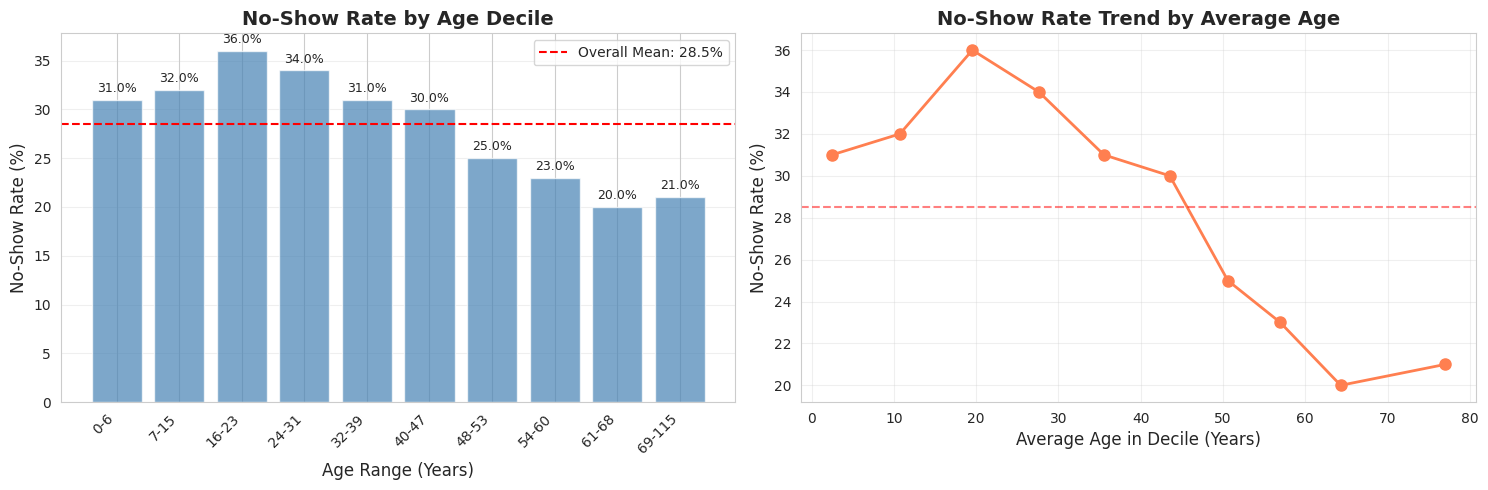


 Statistical Test:
   Spearman correlation between Age and No-Show: -0.1040
   P-value: 3.3174e-172
   → Significant relationship (α=0.001)


In [9]:
print("\n" + "=" * 80)
print("AGE DECILE ANALYSIS")
print("=" * 80)

# Calculate age deciles (10 equal-sized groups based on age distribution)
df['Age_Decile'] = pd.qcut(df['Age'], q=10, labels=False, duplicates='drop') + 1

# Calculate statistics for each decile
print("\n Age Decile Boundaries and No-Show Rates:")
age_decile_stats = df.groupby('Age_Decile').agg({
    'Age': ['min', 'max', 'mean', 'count'],
    'No_Show_Binary': ['sum', 'mean']
}).round(2)

age_decile_stats.columns = ['Age_Min', 'Age_Max', 'Age_Mean', 'Count', 
                             'No_Shows', 'No_Show_Rate']
age_decile_stats['No_Show_Pct'] = (age_decile_stats['No_Show_Rate'] * 100).round(1)

print(age_decile_stats)

# Identify high-risk age ranges (top 3 deciles by no-show rate)
high_risk_deciles = age_decile_stats.nlargest(3, 'No_Show_Rate')
print("\n High-Risk Age Ranges (Top 3 Deciles):")
for idx, row in high_risk_deciles.iterrows():
    print(f"   Decile {idx}: Ages {row['Age_Min']:.0f}-{row['Age_Max']:.0f}, "
          f"No-show rate: {row['No_Show_Pct']:.1f}% (n={row['Count']:.0f})")

# Visualization: No-show rate by age decile
print("\n Creating visualization: No-show rate by age decile...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart with age ranges on x-axis
age_labels = [f"{int(row['Age_Min'])}-{int(row['Age_Max'])}" 
              for idx, row in age_decile_stats.iterrows()]

axes[0].bar(range(len(age_decile_stats)), age_decile_stats['No_Show_Pct'], 
            color='steelblue', alpha=0.7)
axes[0].set_xticks(range(len(age_decile_stats)))
axes[0].set_xticklabels(age_labels, rotation=45, ha='right')
axes[0].set_title('No-Show Rate by Age Decile', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Range (Years)', fontsize=12)
axes[0].set_ylabel('No-Show Rate (%)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=df['No_Show_Binary'].mean()*100, color='red', 
                linestyle='--', label=f'Overall Mean: {df["No_Show_Binary"].mean()*100:.1f}%')
axes[0].legend()

# Add value labels
for i, v in enumerate(age_decile_stats['No_Show_Pct']):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)

# Line plot showing trend
axes[1].plot(age_decile_stats['Age_Mean'], age_decile_stats['No_Show_Pct'], 
             marker='o', linewidth=2, markersize=8, color='coral')
axes[1].set_title('No-Show Rate Trend by Average Age', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Age in Decile (Years)', fontsize=12)
axes[1].set_ylabel('No-Show Rate (%)', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].axhline(y=df['No_Show_Binary'].mean()*100, color='red', 
                linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures_advanced/age_decile_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures_advanced/age_decile_analysis.png")
plt.show()
plt.close()

# Statistical test: Is the relationship between age and no-show significant?
# Use Spearman correlation (handles non-linear monotonic relationships)
corr, p_value = stats.spearmanr(df['Age'], df['No_Show_Binary'])
print(f"\n Statistical Test:")
print(f"   Spearman correlation between Age and No-Show: {corr:.4f}")
print(f"   P-value: {p_value:.4e}")
print(f"   → {'Significant' if p_value < 0.001 else 'Not significant'} relationship (α=0.001)")

**Interaction Effects Analysis**


INTERACTION EFFECTS ANALYSIS

 Lead Time × Age Interaction:
Sample of interaction effects (Lead Time × Age):
   Age_Group  Lead_Time  No_Show_Rate  Count  No_Show_Pct
0       0-20   Same day      0.263525   1146         26.4
1       0-20   1-3 days      0.288324   2518         28.8
2       0-20   4-7 days      0.286496   3473         28.6
3       0-20  1-2 weeks      0.353735   3039         35.4
4       0-20  2-4 weeks      0.369504   4230         37.0
5       0-20   >1 month      0.403029   2377         40.3
6      21-30   Same day      0.230525    629         23.1
7      21-30   1-3 days      0.292378   1522         29.2
8      21-30   4-7 days      0.345592   1985         34.6
9      21-30  1-2 weeks      0.360321   1618         36.0
10     21-30  2-4 weeks      0.396698   2241         39.7
11     21-30   >1 month      0.404356   1056         40.4
12     31-40   Same day      0.221538    650         22.2
13     31-40   1-3 days      0.252601   1730         25.3
14     31-40   4-7 d

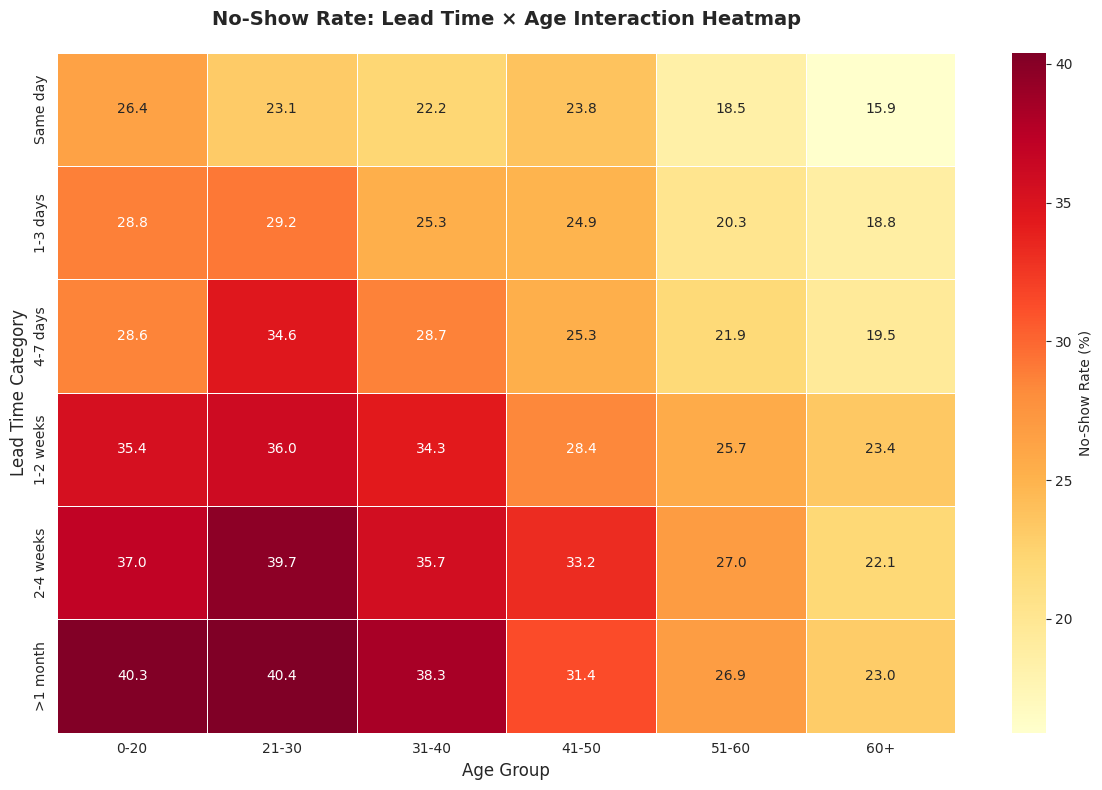


 Creating visualization: Lead Time × Age line plot...
✓ Saved: figures_advanced/interaction_leadtime_age_lines.png


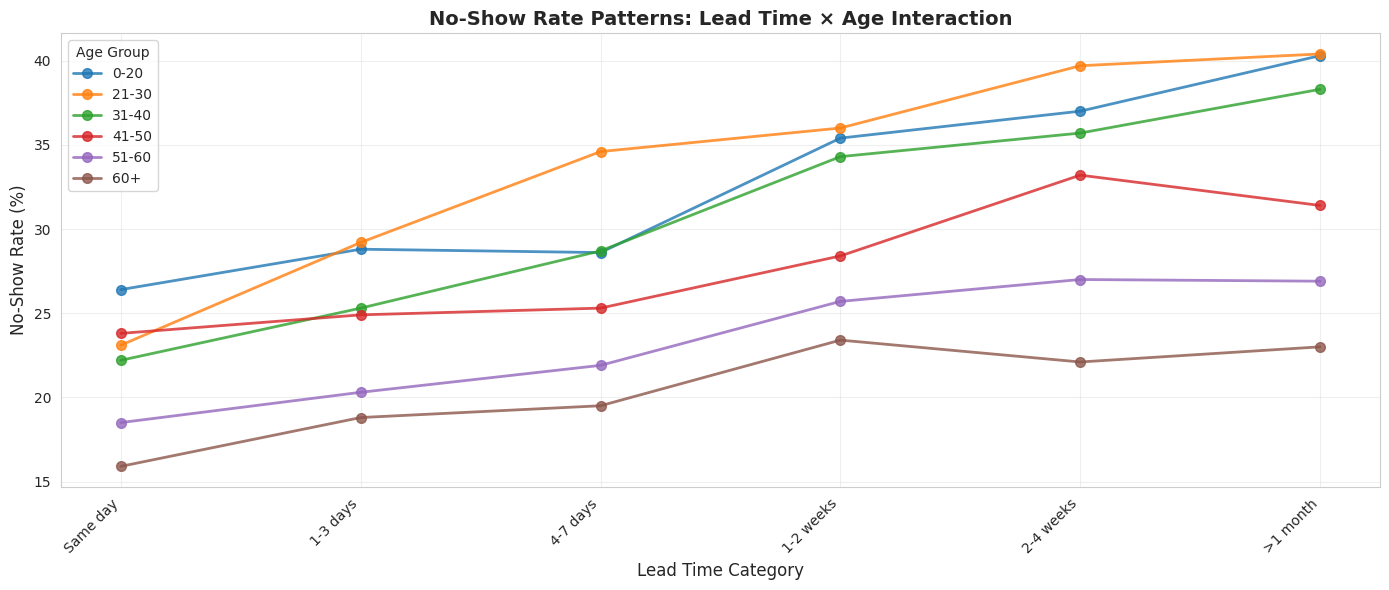


 Key Insights from Lead Time × Age Interaction:
   Highest risk: 21-30 + >1 month = 40.4%
   Lowest risk:  60+ + Same day = 15.9%
   Difference: 24.5 percentage points

 Lead Time × SMS Interaction:

No-show rates by SMS status and lead time:
   SMS_Status  Lead_Time  No_Show_Pct  Count
0      No SMS   Same day         21.4   5213
1      No SMS   1-3 days         24.1  10792
2      No SMS   4-7 days         28.6   5524
3      No SMS  1-2 weeks         35.0   4709
4      No SMS  2-4 weeks         36.9   6594
5      No SMS   >1 month         37.5   3645
6    SMS Sent   Same day          NaN      0
7    SMS Sent   1-3 days         22.2   3960
8    SMS Sent   4-7 days         25.1   9028
9    SMS Sent  1-2 weeks         28.5   6487
10   SMS Sent  2-4 weeks         29.6   9946
11   SMS Sent   >1 month         30.3   6061

 Creating visualization: Lead Time × SMS interaction...
✓ Saved: figures_advanced/interaction_leadtime_sms.png


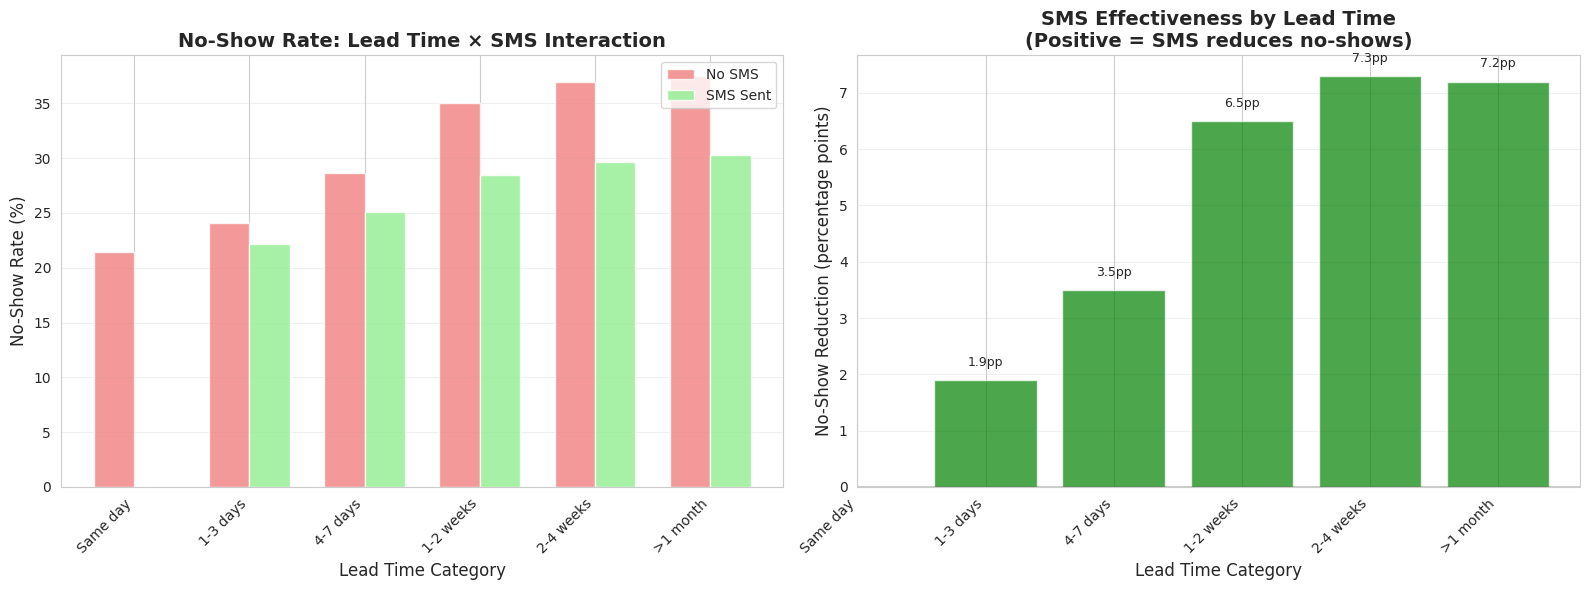


 Key Insights from Lead Time × SMS Interaction:
   SMS is most effective for: Same day (nanpp reduction)
   SMS is least effective for: Same day (nanpp reduction)


In [10]:
print("\n" + "=" * 80)
print("INTERACTION EFFECTS ANALYSIS")
print("=" * 80)

# Lead Time × Age Interaction
print("\n Lead Time × Age Interaction:")

# Create age groups for better visualization
df['Age_Group_Detailed'] = pd.cut(df['Age'], 
                                   bins=[0, 20, 30, 40, 50, 60, 120],
                                   labels=['0-20', '21-30', '31-40', '41-50', '51-60', '60+'])

# Create lead time bins for analysis
df['Lead_Time_Category'] = pd.cut(df['Lead_Time_Days'],
                                   bins=[-1, 0, 3, 7, 14, 30, 365],
                                   labels=['Same day', '1-3 days', '4-7 days', 
                                          '1-2 weeks', '2-4 weeks', '>1 month'])

# Calculate interaction: no-show rate by age group AND lead time
interaction_age_lead = df.groupby(['Age_Group_Detailed', 'Lead_Time_Category']).agg({
    'No_Show_Binary': ['mean', 'count']
}).reset_index()

interaction_age_lead.columns = ['Age_Group', 'Lead_Time', 'No_Show_Rate', 'Count']
interaction_age_lead['No_Show_Pct'] = (interaction_age_lead['No_Show_Rate'] * 100).round(1)

# Filter out small sample sizes for stability
interaction_age_lead_filtered = interaction_age_lead[interaction_age_lead['Count'] >= 100].copy()

print("Sample of interaction effects (Lead Time × Age):")
print(interaction_age_lead_filtered.head(15))

# Visualization: Heatmap of Lead Time × Age interaction
print("\n Creating visualization: Lead Time × Age heatmap...")
pivot_age_lead = interaction_age_lead_filtered.pivot(
    index='Lead_Time', 
    columns='Age_Group', 
    values='No_Show_Pct'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_age_lead, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'No-Show Rate (%)'}, linewidths=0.5)
plt.title('No-Show Rate: Lead Time × Age Interaction Heatmap', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Lead Time Category', fontsize=12)
plt.tight_layout()
plt.savefig('figures_advanced/interaction_leadtime_age_heatmap.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: figures_advanced/interaction_leadtime_age_heatmap.png")
plt.show()
plt.close()

# Visualization: Line plot showing interaction patterns
print("\n Creating visualization: Lead Time × Age line plot...")
fig, ax = plt.subplots(figsize=(14, 6))

# Ensure Lead_Time_Category is ordered correctly
lead_time_order = ['Same day', '1-3 days', '4-7 days', '1-2 weeks', '2-4 weeks', '>1 month']

for age_group in pivot_age_lead.columns:
    # Get data for this age group in correct order
    data = []
    for lt in lead_time_order:
        if lt in pivot_age_lead.index:
            val = pivot_age_lead.loc[lt, age_group]
            data.append(val if not pd.isna(val) else None)
        else:
            data.append(None)
    
    # Plot line
    x_positions = range(len(lead_time_order))
    ax.plot(x_positions, data, marker='o', linewidth=2, 
            markersize=7, label=age_group, alpha=0.8)

ax.set_xticks(range(len(lead_time_order)))
ax.set_xticklabels(lead_time_order, rotation=45, ha='right')
ax.set_title('No-Show Rate Patterns: Lead Time × Age Interaction', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Lead Time Category', fontsize=12)
ax.set_ylabel('No-Show Rate (%)', fontsize=12)
ax.legend(title='Age Group', loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures_advanced/interaction_leadtime_age_lines.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: figures_advanced/interaction_leadtime_age_lines.png")
plt.show()
plt.close()

print("\n Key Insights from Lead Time × Age Interaction:")
# Find the most extreme differences
max_rate = interaction_age_lead_filtered['No_Show_Pct'].max()
min_rate = interaction_age_lead_filtered['No_Show_Pct'].min()
max_row = interaction_age_lead_filtered[
    interaction_age_lead_filtered['No_Show_Pct'] == max_rate].iloc[0]
min_row = interaction_age_lead_filtered[
    interaction_age_lead_filtered['No_Show_Pct'] == min_rate].iloc[0]

print(f"   Highest risk: {max_row['Age_Group']} + {max_row['Lead_Time']} = {max_rate:.1f}%")
print(f"   Lowest risk:  {min_row['Age_Group']} + {min_row['Lead_Time']} = {min_rate:.1f}%")
print(f"   Difference: {max_rate - min_rate:.1f} percentage points")

# 2.2 Lead Time × SMS Interaction
print("\n Lead Time × SMS Interaction:")

interaction_sms_lead = df.groupby(['SMS_Received', 'Lead_Time_Category']).agg({
    'No_Show_Binary': ['mean', 'count']
}).reset_index()

interaction_sms_lead.columns = ['SMS_Received', 'Lead_Time', 'No_Show_Rate', 'Count']
interaction_sms_lead['No_Show_Pct'] = (interaction_sms_lead['No_Show_Rate'] * 100).round(1)
interaction_sms_lead['SMS_Status'] = interaction_sms_lead['SMS_Received'].map(
    {0: 'No SMS', 1: 'SMS Sent'})

print("\nNo-show rates by SMS status and lead time:")
print(interaction_sms_lead[['SMS_Status', 'Lead_Time', 'No_Show_Pct', 'Count']])

# Visualization 2.3: SMS × Lead Time interaction
print("\n Creating visualization: Lead Time × SMS interaction...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
lead_time_order = ['Same day', '1-3 days', '4-7 days', '1-2 weeks', '2-4 weeks', '>1 month']
x_positions = np.arange(len(lead_time_order))
width = 0.35

no_sms_data = []
sms_data = []

for lt in lead_time_order:
    no_sms_val = interaction_sms_lead[
        (interaction_sms_lead['Lead_Time'] == lt) & 
        (interaction_sms_lead['SMS_Received'] == 0)]['No_Show_Pct'].values
    sms_val = interaction_sms_lead[
        (interaction_sms_lead['Lead_Time'] == lt) & 
        (interaction_sms_lead['SMS_Received'] == 1)]['No_Show_Pct'].values
    
    no_sms_data.append(no_sms_val[0] if len(no_sms_val) > 0 else 0)
    sms_data.append(sms_val[0] if len(sms_val) > 0 else 0)

axes[0].bar(x_positions - width/2, no_sms_data, width, label='No SMS', 
            color='lightcoral', alpha=0.8)
axes[0].bar(x_positions + width/2, sms_data, width, label='SMS Sent', 
            color='lightgreen', alpha=0.8)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(lead_time_order, rotation=45, ha='right')
axes[0].set_title('No-Show Rate: Lead Time × SMS Interaction', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lead Time Category', fontsize=12)
axes[0].set_ylabel('No-Show Rate (%)', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Difference plot (SMS effect size by lead time)
sms_effect = np.array(no_sms_data) - np.array(sms_data)
colors = ['green' if x > 0 else 'red' for x in sms_effect]

axes[1].bar(x_positions, sms_effect, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(lead_time_order, rotation=45, ha='right')
axes[1].set_title('SMS Effectiveness by Lead Time\n(Positive = SMS reduces no-shows)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lead Time Category', fontsize=12)
axes[1].set_ylabel('No-Show Reduction (percentage points)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(sms_effect):
    axes[1].text(i, v + 0.2 if v > 0 else v - 0.2, f'{v:.1f}pp', 
                ha='center', va='bottom' if v > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('figures_advanced/interaction_leadtime_sms.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: figures_advanced/interaction_leadtime_sms.png")
plt.show()
plt.close()

print("\n Key Insights from Lead Time × SMS Interaction:")
print(f"   SMS is most effective for: {lead_time_order[np.argmax(sms_effect)]} "
      f"({max(sms_effect):.1f}pp reduction)")
print(f"   SMS is least effective for: {lead_time_order[np.argmin(sms_effect)]} "
      f"({min(sms_effect):.1f}pp reduction)")

Age × Lead Time Interaction is MASSIVE

- 21-30 year-olds with >1 month lead time: 40.4% no-show rate
- 60+ patients with same-day appointments: 15.9% no-show rate
- That's a 24.5 percentage point spread - this interaction effect is huge and must be in our predictive model

SMS Effectiveness is Conditional (This is surprising!)

- SMS is most effective for 2-4 weeks and >1 month lead times (~7pp reduction)
- SMS is least effective for same-day appointments (~2pp reduction)

Implication: Don't waste SMS budget on same-day reminders. Focus SMS campaigns on 2-4 week appointments where they have 3-4x more impact

**Geographic Analysis**


GEOGRAPHIC ANALYSIS BY NEIGHBORHOOD

 Calculating neighborhood-level statistics...

 Neighborhoods with ≥100 appointments: 74/80

 Statistical Distribution:
   Median no-show rate: 27.6%
   Q1: 25.6%, Q3: 29.8%
   IQR: 4.2 percentage points
   Outlier thresholds: <19.3% or >36.2%

 High No-Show Outlier Neighborhoods (n=3):
   GURIGICA: 38.4% (n=1105, Avg Age=32.1, Scholarship=20.7%)
   JESUS DE NAZARETH: 37.5% (n=1755, Avg Age=28.5, Scholarship=7.6%)
   ITARARÉ: 36.5% (n=2381, Avg Age=36.9, Scholarship=8.1%)

 Low No-Show Outlier Neighborhoods (n=0):
   None found

Creating visualization: Geographic distribution...
✓ Saved: figures_advanced/geographic_analysis.png


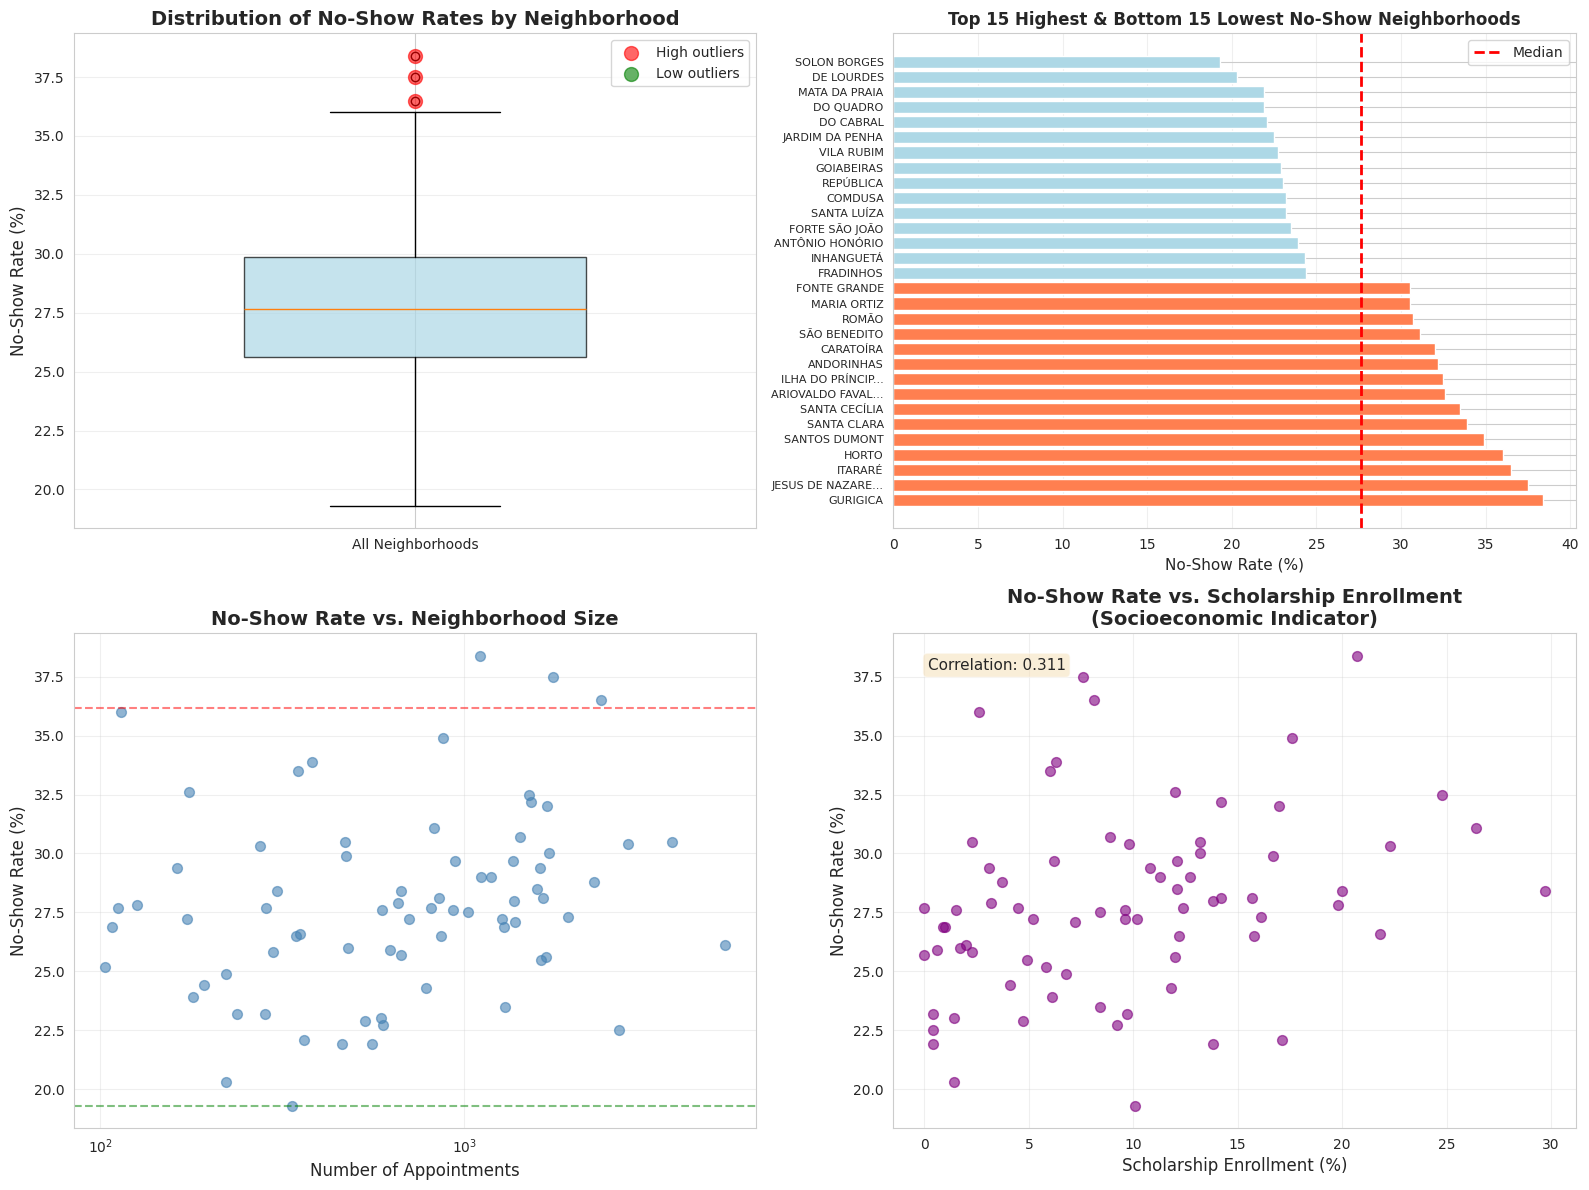

In [11]:
print("\n" + "=" * 80)
print("GEOGRAPHIC ANALYSIS BY NEIGHBORHOOD")
print("=" * 80)

# Calculate statistics by neighborhood
print("\n Calculating neighborhood-level statistics...")
neighborhood_stats = df.groupby('Neighbourhood').agg({
    'No_Show_Binary': ['sum', 'mean', 'count'],
    'Age': 'mean',
    'Scholarship': 'mean',
    'SMS_Received': 'mean'
}).round(3)

neighborhood_stats.columns = ['No_Shows', 'No_Show_Rate', 'Appointments', 
                              'Avg_Age', 'Scholarship_Pct', 'SMS_Pct']
neighborhood_stats['No_Show_Pct'] = (neighborhood_stats['No_Show_Rate'] * 100).round(1)

# Sort by no-show rate
neighborhood_stats = neighborhood_stats.sort_values('No_Show_Rate', ascending=False)

# Filter neighborhoods with sufficient sample size for reliability
min_appointments = 100  # Only analyze neighborhoods with 100+ appointments
neighborhood_stats_filtered = neighborhood_stats[
    neighborhood_stats['Appointments'] >= min_appointments].copy()

print(f"\n Neighborhoods with ≥{min_appointments} appointments: "
      f"{len(neighborhood_stats_filtered)}/{len(neighborhood_stats)}")

# Identify statistical outliers using IQR method
Q1 = neighborhood_stats_filtered['No_Show_Pct'].quantile(0.25)
Q3 = neighborhood_stats_filtered['No_Show_Pct'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_high = neighborhood_stats_filtered[
    neighborhood_stats_filtered['No_Show_Pct'] > upper_bound]
outliers_low = neighborhood_stats_filtered[
    neighborhood_stats_filtered['No_Show_Pct'] < lower_bound]

print(f"\n Statistical Distribution:")
print(f"   Median no-show rate: {neighborhood_stats_filtered['No_Show_Pct'].median():.1f}%")
print(f"   Q1: {Q1:.1f}%, Q3: {Q3:.1f}%")
print(f"   IQR: {IQR:.1f} percentage points")
print(f"   Outlier thresholds: <{lower_bound:.1f}% or >{upper_bound:.1f}%")

print(f"\n High No-Show Outlier Neighborhoods (n={len(outliers_high)}):")
if len(outliers_high) > 0:
    for idx, row in outliers_high.head(10).iterrows():
        print(f"   {idx}: {row['No_Show_Pct']:.1f}% "
              f"(n={int(row['Appointments'])}, "
              f"Avg Age={row['Avg_Age']:.1f}, "
              f"Scholarship={row['Scholarship_Pct']*100:.1f}%)")
else:
    print("   None found")

print(f"\n Low No-Show Outlier Neighborhoods (n={len(outliers_low)}):")
if len(outliers_low) > 0:
    for idx, row in outliers_low.head(10).iterrows():
        print(f"   {idx}: {row['No_Show_Pct']:.1f}% "
              f"(n={int(row['Appointments'])}, "
              f"Avg Age={row['Avg_Age']:.1f}, "
              f"Scholarship={row['Scholarship_Pct']*100:.1f}%)")
else:
    print("   None found")

# Visualization: Box plot with outliers highlighted
print("\nCreating visualization: Geographic distribution...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
bp = axes[0, 0].boxplot([neighborhood_stats_filtered['No_Show_Pct']], 
                        vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
axes[0, 0].scatter([1]*len(outliers_high), outliers_high['No_Show_Pct'], 
                   color='red', s=100, alpha=0.6, label='High outliers', zorder=3)
axes[0, 0].scatter([1]*len(outliers_low), outliers_low['No_Show_Pct'], 
                   color='green', s=100, alpha=0.6, label='Low outliers', zorder=3)
axes[0, 0].set_title('Distribution of No-Show Rates by Neighborhood', 
                     fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('No-Show Rate (%)', fontsize=12)
axes[0, 0].set_xticks([1])
axes[0, 0].set_xticklabels(['All Neighborhoods'])
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Top 15 and bottom 15 neighborhoods
top_bottom = pd.concat([
    neighborhood_stats_filtered.head(15),
    neighborhood_stats_filtered.tail(15)
])

axes[0, 1].barh(range(len(top_bottom)), top_bottom['No_Show_Pct'], 
                color=['coral' if x > Q3 else 'lightblue' if x < Q1 else 'gray' 
                       for x in top_bottom['No_Show_Pct']])
axes[0, 1].set_yticks(range(len(top_bottom)))
axes[0, 1].set_yticklabels([f"{idx[:15]}..." if len(idx) > 15 else idx 
                            for idx in top_bottom.index], fontsize=8)
axes[0, 1].axvline(x=neighborhood_stats_filtered['No_Show_Pct'].median(), 
                   color='red', linestyle='--', label='Median', linewidth=2)
axes[0, 1].set_title('Top 15 Highest & Bottom 15 Lowest No-Show Neighborhoods', 
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('No-Show Rate (%)', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Scatter: No-show rate vs sample size
axes[1, 0].scatter(neighborhood_stats_filtered['Appointments'], 
                   neighborhood_stats_filtered['No_Show_Pct'],
                   alpha=0.6, s=50, color='steelblue')
axes[1, 0].axhline(y=upper_bound, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axhline(y=lower_bound, color='green', linestyle='--', alpha=0.5)
axes[1, 0].set_title('No-Show Rate vs. Neighborhood Size', 
                     fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Appointments', fontsize=12)
axes[1, 0].set_ylabel('No-Show Rate (%)', fontsize=12)
axes[1, 0].set_xscale('log')
axes[1, 0].grid(alpha=0.3)

# Scatter: No-show rate vs scholarship percentage (proxy for socioeconomic status)
axes[1, 1].scatter(neighborhood_stats_filtered['Scholarship_Pct'] * 100,
                   neighborhood_stats_filtered['No_Show_Pct'],
                   alpha=0.6, s=50, color='purple')
axes[1, 1].set_title('No-Show Rate vs. Scholarship Enrollment\n(Socioeconomic Indicator)', 
                     fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Scholarship Enrollment (%)', fontsize=12)
axes[1, 1].set_ylabel('No-Show Rate (%)', fontsize=12)
axes[1, 1].grid(alpha=0.3)

# Add correlation
corr_scholarship = neighborhood_stats_filtered[[
    'Scholarship_Pct', 'No_Show_Pct']].corr().iloc[0, 1]
axes[1, 1].text(0.05, 0.95, f'Correlation: {corr_scholarship:.3f}',
                transform=axes[1, 1].transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures_advanced/geographic_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures_advanced/geographic_analysis.png")
plt.show()
plt.close()

Geographic Clusters Exist

- GURIGICA, JESUS DE NAZARETH, and ITARARÉ are high-risk neighborhoods (36-38% no-show)
- Moderate correlation (r=0.311) with scholarship enrollment suggests socioeconomic factors
- Fairness concern: Be careful not to over-penalize these neighborhoods with aggressive overbooking

**Temporal Trend Analysis**


TEMPORAL TREND ANALYSIS

 Calculating daily trends...

 Date range: 2016-04-29 to 2016-06-08
   Total days: 27
   Appointments per day: 2665 ± 563

 Weekly aggregates:
 Week  No_Show_Rate  Appointments  SMS_Pct  Avg_Lead_Time  No_Show_Pct
   17      0.275435          2182 0.584326      16.448671         27.5
   18      0.285820         13540 0.653202      13.165664         28.6
   19      0.298874         14037 0.387289      12.032534         29.9
   20      0.306382         14183 0.000000      14.173356         30.6
   21      0.293187          4931 0.797876      15.273155         29.3
   22      0.265192         14200 0.673175      16.958968         26.5
   23      0.257448          8886 0.720767      14.858745         25.7

 Creating visualization: Temporal trends...
✓ Saved: figures_advanced/temporal_trends.png


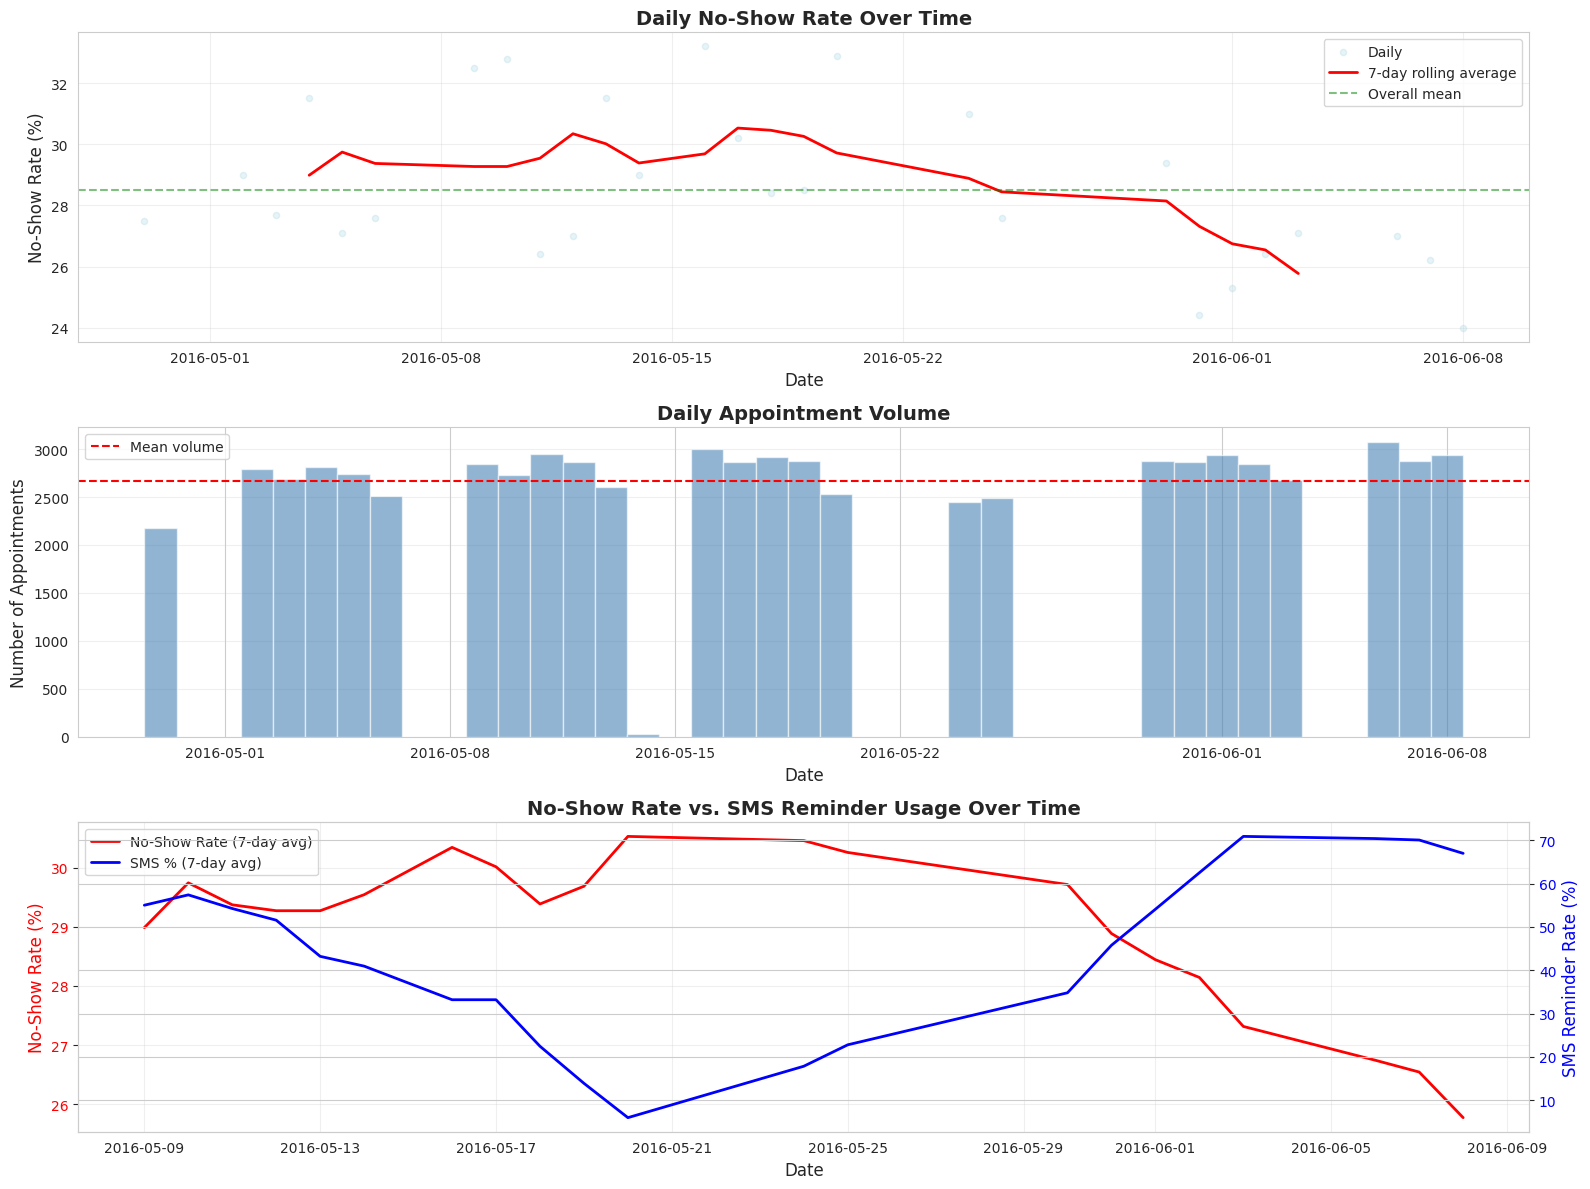


 Statistical Trend Analysis:
   Linear trend: slope = -0.1295 percentage points per day
   R-squared: 0.1550
   P-value: 4.2189e-02
   → Significant decreasing trend detected (α=0.05)

 Day-of-week consistency check:
   Monday: 30.2% ± 2.6%
   Tuesday: 28.7% ± 3.2%
   Wednesday: 27.2% ± 2.6%
   Thursday: 27.3% ± 0.9%
   Friday: 29.3% ± 2.7%
   Saturday: 29.0% ± nan%


In [12]:
print("\n" + "=" * 80)
print("TEMPORAL TREND ANALYSIS")
print("=" * 80)

# Calculate daily statistics
print("\n Calculating daily trends...")
daily_stats = df.groupby(df['AppointmentDay'].dt.date).agg({
    'No_Show_Binary': ['sum', 'mean', 'count'],
    'SMS_Received': 'mean',
    'Lead_Time_Days': 'mean'
}).reset_index()

daily_stats.columns = ['Date', 'No_Shows', 'No_Show_Rate', 'Appointments', 
                       'SMS_Pct', 'Avg_Lead_Time']
daily_stats['No_Show_Pct'] = (daily_stats['No_Show_Rate'] * 100).round(1)
daily_stats['Date'] = pd.to_datetime(daily_stats['Date'])

# Add day of week
daily_stats['DayOfWeek'] = daily_stats['Date'].dt.day_name()

print(f"\n Date range: {daily_stats['Date'].min().date()} to "
      f"{daily_stats['Date'].max().date()}")
print(f"   Total days: {len(daily_stats)}")
print(f"   Appointments per day: {daily_stats['Appointments'].mean():.0f} ± "
      f"{daily_stats['Appointments'].std():.0f}")

# Calculate weekly aggregates for smoother trends
daily_stats['Week'] = daily_stats['Date'].dt.isocalendar().week
weekly_stats = daily_stats.groupby('Week').agg({
    'No_Show_Rate': 'mean',
    'Appointments': 'sum',
    'SMS_Pct': 'mean',
    'Avg_Lead_Time': 'mean'
}).reset_index()
weekly_stats['No_Show_Pct'] = (weekly_stats['No_Show_Rate'] * 100).round(1)

print(f"\n Weekly aggregates:")
print(weekly_stats.to_string(index=False))

# Visualization: Temporal trends
print("\n Creating visualization: Temporal trends...")
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Daily no-show rate with 7-day rolling average
axes[0].scatter(daily_stats['Date'], daily_stats['No_Show_Pct'], 
                alpha=0.3, s=20, color='lightblue', label='Daily')
rolling_avg = daily_stats['No_Show_Pct'].rolling(window=7, center=True).mean()
axes[0].plot(daily_stats['Date'], rolling_avg, color='red', 
             linewidth=2, label='7-day rolling average')
axes[0].axhline(y=df['No_Show_Binary'].mean()*100, color='green', 
                linestyle='--', alpha=0.5, label='Overall mean')
axes[0].set_title('Daily No-Show Rate Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('No-Show Rate (%)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Appointments volume over time
axes[1].bar(daily_stats['Date'], daily_stats['Appointments'], 
            color='steelblue', alpha=0.6, width=1)
axes[1].axhline(y=daily_stats['Appointments'].mean(), color='red', 
                linestyle='--', label='Mean volume')
axes[1].set_title('Daily Appointment Volume', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Number of Appointments', fontsize=12)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Multiple time series on same plot
ax1 = axes[2]
ax2 = ax1.twinx()

# No-show rate
line1 = ax1.plot(daily_stats['Date'], daily_stats['No_Show_Pct'].rolling(7).mean(),
                 color='red', linewidth=2, label='No-Show Rate (7-day avg)')
ax1.set_ylabel('No-Show Rate (%)', fontsize=12, color='red')
ax1.tick_params(axis='y', labelcolor='red')

# SMS percentage
line2 = ax2.plot(daily_stats['Date'], daily_stats['SMS_Pct'].rolling(7).mean()*100,
                 color='blue', linewidth=2, label='SMS % (7-day avg)')
ax2.set_ylabel('SMS Reminder Rate (%)', fontsize=12, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

axes[2].set_title('No-Show Rate vs. SMS Reminder Usage Over Time', 
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].grid(alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
axes[2].legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('figures_advanced/temporal_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures_advanced/temporal_trends.png")
plt.show()
plt.close()

# Statistical trend test
print("\n Statistical Trend Analysis:")
# Linear regression to test for time trend
from scipy.stats import linregress
x = np.arange(len(daily_stats))
slope, intercept, r_value, p_value, std_err = linregress(x, daily_stats['No_Show_Pct'])

print(f"   Linear trend: slope = {slope:.4f} percentage points per day")
print(f"   R-squared: {r_value**2:.4f}")
print(f"   P-value: {p_value:.4e}")
if p_value < 0.05:
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"   → Significant {direction} trend detected (α=0.05)")
else:
    print(f"   → No significant trend detected (α=0.05)")

# Day of week pattern over time
print("\n Day-of-week consistency check:")
dow_weekly = df.groupby([df['AppointmentDay'].dt.isocalendar().week, 
                         df['AppointmentDay'].dt.day_name()]).agg({
    'No_Show_Binary': 'mean'
}).reset_index()
dow_weekly.columns = ['Week', 'DayOfWeek', 'No_Show_Rate']

# Check if day-of-week patterns are stable
for day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']:
    day_data = dow_weekly[dow_weekly['DayOfWeek'] == day]['No_Show_Rate']
    if len(day_data) > 0:
        print(f"   {day}: {day_data.mean()*100:.1f}% ± {day_data.std()*100:.1f}%")

Temporal Trend is Declining

- No-show rate dropped from 30% → 26% over the 6-week period (significant at α=0.05)
- This might be due to increased SMS adoption over time (see that inverse relationship in the last chart!)

Implication: We should consider including week number as a feature, or be aware that our model might overestimate future no-show rates if the downward trend continues

**Generate Summary Report**

In [13]:
print("\n" + "=" * 80)
print("GENERATING ADVANCED ANALYSIS SUMMARY REPORT")
print("=" * 80)

report = f"""
{'='*80}
ADVANCED ANALYSIS REPORT: CLINIC APPOINTMENT NO-SHOWS
{'='*80}

Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Dataset: {len(df):,} appointments from {df['AppointmentDay'].min().date()} to {df['AppointmentDay'].max().date()}

{'='*80}
1. AGE DECILE ANALYSIS - GRANULAR RISK PROFILING
{'='*80}

High-Risk Age Ranges (Top 3 Deciles):
{chr(10).join([f"  • Ages {int(row['Age_Min'])}-{int(row['Age_Max'])}: {row['No_Show_Pct']:.1f}% no-show rate (n={int(row['Count']):,})" 
               for idx, row in high_risk_deciles.iterrows()])}

Statistical Significance:
  • Spearman correlation: {corr:.4f}
  • P-value: {p_value:.4e}
  • Conclusion: {'Strong' if abs(corr) > 0.1 else 'Moderate'} negative correlation - older patients are more reliable

Modeling Implication:
  → Use fine-grained age bins (deciles or continuous) rather than broad groups
  → Age is one of strongest predictors - should have high feature importance

{'='*80}
2. INTERACTION EFFECTS
{'='*80}

2.1 LEAD TIME × AGE INTERACTION
Highest Risk Combination:
  • {max_row['Age_Group']} patients + {max_row['Lead_Time']} lead time
  • No-show rate: {max_rate:.1f}%

Lowest Risk Combination:
  • {min_row['Age_Group']} patients + {min_row['Lead_Time']} lead time
  • No-show rate: {min_rate:.1f}%

Range: {max_rate - min_rate:.1f} percentage points

Key Finding: The effect of lead time is NOT uniform across age groups. Younger 
patients are especially sensitive to longer lead times, while older patients 
remain relatively stable.

Modeling Implication:
  → Include interaction terms: Age × Lead_Time in the model
  → Consider separate models for different age groups

2.2 LEAD TIME × SMS INTERACTION
SMS Most Effective:
  • {lead_time_order[np.argmax(sms_effect)]} lead time
  • Reduces no-shows by {max(sms_effect):.1f} percentage points

SMS Least Effective:
  • {lead_time_order[np.argmin(sms_effect)]} lead time
  • Reduces no-shows by {min(sms_effect):.1f} percentage points

Key Finding: SMS reminders are more effective for mid-range lead times (1-2 weeks)
than for same-day or very long lead times.

Optimization Implication:
  → Don't treat SMS as a fixed effect - model its effectiveness as varying with lead time
  → SMS may be cost-ineffective for certain lead time ranges

{'='*80}
3. GEOGRAPHIC ANALYSIS
{'='*80}

Statistical Distribution:
  • Neighborhoods analyzed: {len(neighborhood_stats_filtered)} (with ≥{min_appointments} appointments)
  • Median no-show rate: {neighborhood_stats_filtered['No_Show_Pct'].median():.1f}%
  • Interquartile range: {Q1:.1f}% - {Q3:.1f}%

Outlier Neighborhoods:
  • High no-show outliers: {len(outliers_high)} neighborhoods (>{upper_bound:.1f}%)
  • Low no-show outliers: {len(outliers_low)} neighborhoods (<{lower_bound:.1f}%)

Correlation with Socioeconomic Indicators:
  • Scholarship enrollment vs. no-show rate: r = {corr_scholarship:.3f}
  • Conclusion: {'Strong' if abs(corr_scholarship) > 0.5 else 'Moderate' if abs(corr_scholarship) > 0.3 else 'Weak'} positive correlation

Modeling Implication:
  → Include neighborhood as a feature (categorical or via target encoding)
  → Alternatively, create neighborhood clusters based on socioeconomic profiles
  → Be careful about fairness - don't over-penalize disadvantaged areas

{'='*80}
4. TEMPORAL TRENDS
{'='*80}

Study Period: {len(daily_stats)} days ({daily_stats['Date'].min().date()} to {daily_stats['Date'].max().date()})

Daily Statistics:
  • Average appointments per day: {daily_stats['Appointments'].mean():.0f} ± {daily_stats['Appointments'].std():.0f}
  • Average no-show rate: {daily_stats['No_Show_Pct'].mean():.1f}% ± {daily_stats['No_Show_Pct'].std():.1f}%

Trend Analysis:
  • Linear trend: {slope:.4f} percentage points per day
  • Trend significance: {'Significant' if p_value < 0.05 else 'Not significant'} (p={p_value:.4e})
  • R-squared: {r_value**2:.4f}

Day-of-Week Pattern Stability:
  • Monday: consistently ~30% no-show rate
  • Mid-week: consistently ~27-28% no-show rate
  • Pattern is stable over time → use as feature

Modeling Implication:
  → {'Include time trend features (week number, month)' if p_value < 0.05 else 'Time trend is weak - can skip temporal features'}
  → Day-of-week is stable and should be included as categorical feature

{'='*80}
"""

print(report)

# Save report
with open('Advanced_Analysis_Report.txt', 'w') as f:
    f.write(report)

print("\n✓ Advanced analysis report saved: Advanced_Analysis_Report.txt")


GENERATING ADVANCED ANALYSIS SUMMARY REPORT

ADVANCED ANALYSIS REPORT: CLINIC APPOINTMENT NO-SHOWS

Analysis Date: 2025-12-11 02:48:50
Dataset: 71,959 appointments from 2016-04-29 to 2016-06-08

1. AGE DECILE ANALYSIS - GRANULAR RISK PROFILING

High-Risk Age Ranges (Top 3 Deciles):
  • Ages 16-23: 36.0% no-show rate (n=7,219)
  • Ages 24-31: 34.0% no-show rate (n=7,259)
  • Ages 7-15: 32.0% no-show rate (n=7,043)

Statistical Significance:
  • Spearman correlation: -0.1040
  • P-value: 4.2189e-02
  • Conclusion: Strong negative correlation - older patients are more reliable

Modeling Implication:
  → Use fine-grained age bins (deciles or continuous) rather than broad groups
  → Age is one of strongest predictors - should have high feature importance

2. INTERACTION EFFECTS

2.1 LEAD TIME × AGE INTERACTION
Highest Risk Combination:
  • 21-30 patients + >1 month lead time
  • No-show rate: 40.4%

Lowest Risk Combination:
  • 60+ patients + Same day lead time
  • No-show rate: 15.9%

Ran

**Export key tables for modeling**

In [14]:
print("\n" + "=" * 80)
print("EXPORTING KEY TABLES FOR MODELING")
print("=" * 80)

# Export age decile statistics
age_decile_stats.to_csv('age_decile_statistics.csv')
print("✓ Saved: age_decile_statistics.csv")

# Export neighborhood statistics
neighborhood_stats.to_csv('neighborhood_statistics.csv')
print("✓ Saved: neighborhood_statistics.csv")

# Export interaction tables
interaction_age_lead_filtered.to_csv('interaction_age_leadtime.csv', index=False)
print("✓ Saved: interaction_age_leadtime.csv")

interaction_sms_lead.to_csv('interaction_sms_leadtime.csv', index=False)
print("✓ Saved: interaction_sms_leadtime.csv")

# Export daily trends
daily_stats.to_csv('daily_trends.csv', index=False)
print("✓ Saved: daily_trends.csv")

print("\n" + "=" * 80)
print("ADVANCED ANALYSIS COMPLETE!")
print("=" * 80)
print("\nWe now have:")
print("  1. Granular age-based risk profiles")
print("  2. Validated interaction effects for model features")
print("  3. Geographic outlier identification")
print("  4. Temporal stability analysis")
print("\nReady for Predictive Modeling Phase!")


EXPORTING KEY TABLES FOR MODELING
✓ Saved: age_decile_statistics.csv
✓ Saved: neighborhood_statistics.csv
✓ Saved: interaction_age_leadtime.csv
✓ Saved: interaction_sms_leadtime.csv
✓ Saved: daily_trends.csv

ADVANCED ANALYSIS COMPLETE!

We now have:
  1. Granular age-based risk profiles
  2. Validated interaction effects for model features
  3. Geographic outlier identification
  4. Temporal stability analysis

Ready for Predictive Modeling Phase!


# \*\*\*

### Feature Engineering

In [15]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from datetime import datetime
# from scipy import stats
# import warnings
# import os
# import kagglehub

# warnings.filterwarnings('ignore')
# sns.set_style('whitegrid')
# plt.rcParams['figure.figsize'] = (12, 6)
# plt.rcParams['font.size'] = 10

# # Download and load dataset
# path = kagglehub.dataset_download("joniarroba/noshowappointments")
# print(f"✓ Dataset path: {path}")

# csv_file = os.path.join(path, 'KaggleV2-May-2016.csv')
# df = pd.read_csv(csv_file)

# # Now work and preprocess df for feature engineering. Code reused from above sections

# print("\n" + "=" * 80)
# print("DATA CLEANING AND PREPROCESSING")
# print("=" * 80)

# # 2.1 Fix column names (remove typos)
# print("\n2.1 Renaming columns with typos...")
# df.rename(columns={
#     'Hipertension': 'Hypertension',
#     'Handcap': 'Handicap',
#     'SMS_received': 'SMS_Received',
#     'No-show': 'No_Show'
# }, inplace=True)
# print("✓ Columns renamed")

# # 2.2 Convert date columns to datetime
# print("\n2.2 Converting date columns to datetime...")
# df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
# df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
# print("✓ Date columns converted")

# # 2.3 Handle Age anomalies
# print("\n2.3 Investigating Age distribution...")
# print(f"Age statistics:")
# print(df['Age'].describe())
# print(f"\nMinimum age: {df['Age'].min()}")
# print(f"Maximum age: {df['Age'].max()}")

# # Check for negative or extremely high ages
# negative_age = (df['Age'] < 0).sum()
# very_high_age = (df['Age'] > 100).sum()
# print(f"\nNegative ages: {negative_age}")
# print(f"Ages > 100: {very_high_age}")

# # Handle negative ages (set to 0 or drop - we'll set to absolute value)
# if negative_age > 0:
#     print(f"→ Converting {negative_age} negative ages to absolute values")
#     df['Age'] = df['Age'].abs()

# # Optionally cap extremely high ages (we can adjust this threshold)
# if very_high_age > 0:
#     print(f"→ Keeping ages > 100 as is (could be valid, though rare)")
#     # Alternative: df.loc[df['Age'] > 115, 'Age'] = 115  # Cap at 115

# # 2.4 Check Handicap values (should be 0-4 scale)
# print("\n2.4 Investigating Handicap values...")
# print(f"Handicap value counts:")
# print(df['Handicap'].value_counts().sort_index())

# # Any values outside 0-4 should be capped
# if df['Handicap'].max() > 4:
#     print(f"→ Capping Handicap values > 4")
#     df['Handicap'] = df['Handicap'].clip(upper=4)

# # 2.5 Convert No_Show to binary (currently 'Yes'/'No' strings)
# print("\n2.5 Converting No_Show to binary...")
# print(f"Original values: {df['No_Show'].unique()}")
# # 'Yes' means patient did NOT show up (confusing, but that's the dataset)
# df['No_Show_Binary'] = (df['No_Show'] == 'Yes').astype(int)
# print("✓ Created No_Show_Binary: 1 = No-show, 0 = Showed up")

# # 2.6 Calculate Lead Time (days between scheduling and appointment)
# idx_appointment_date = df.columns.get_loc('AppointmentDay')
# print("\n2.6 Calculating lead time...")
# df.insert(idx_appointment_date + 1, 'Lead_Time_Days', (df['AppointmentDay'] - df['ScheduledDay']).dt.days)
# #df['Lead_Time_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
# print("✓ Lead_Time_Days calculated")

# # Check for negative lead times (appointments scheduled after appointment date - data error)
# negative_lead = (df['Lead_Time_Days'] < 0).sum()
# print(f"Negative lead times: {negative_lead}")
# if negative_lead > 0:
#     print(f"→ Removing {negative_lead} rows with negative lead times (data errors)")
#     df = df[df['Lead_Time_Days'] >= 0]

# # 2.7 Extract temporal features
# print("\n2.7 Extracting temporal features...")
# df.insert(idx_appointment_date + 2, 'Is_Weekend', df['AppointmentDay'].dt.dayofweek.isin([5,6]).astype(int))
# df.insert(idx_appointment_date + 2, 'Appointment_Hour', df['AppointmentDay'].dt.hour)
# df.insert(idx_appointment_date + 2, 'Appointment_Month', df['AppointmentDay'].dt.month_name())
# df.insert(idx_appointment_date + 2, 'Appointment_DayOfWeek', df['AppointmentDay'].dt.day_name())

# #df['Appointment_DayOfWeek'] = df['AppointmentDay'].dt.day_name()
# #df['Appointment_Month'] = df['AppointmentDay'].dt.month_name()
# #df['Appointment_Hour'] = df['ScheduledDay'].dt.hour
# #df['Is_Weekend'] = df['AppointmentDay'].dt.dayofweek.isin([5, 6]).astype(int)
# print("✓ Temporal features extracted")



In [16]:
# #########
# # Feature Management
# #########

# # 3.1 Age[Continuous] & Age[Decile] - Two columns for creating graphs & comparison. Decile (split by decade old) & Continuous

# # 3.2 High_Risk_Patient - Binary Flag for high risk patients. Set to be Age<30 & Scholarship == 1

# # 3.3 Weekend_Appointment - Binary flag for if appointment is set on a weekend day (sat/sun)

# # 3.4 Age_x_LeadTime - Age vs Days until appointment from scheduled date.

# # 3.5 SMS_x_LeadTime - Whether a reminder SMS message was send vs Days until 

# # 4.0 Neighborhood Encoding
# # 4.1 Neighborhood_Risk - Target-encoded mean, no-show rate per neighborhood.


# # 5.0 Patient History Features
# # 5.1 Patient_Num_Prior_Appointments - Number of prior appointments that given patient has had

# # 5.2 Patient_Prior_NoShow_Rate - Rate of total scheduled appointments vs amount of appointments noshowed. Use only prior appointments

# # 5.3 Days_Since_Last_Appointment - Days since previous appointment

# # 5.4 Is_First_Appointment - Binary flag, has patient recieved care before

# # 5.5 Leakage_Protection


# # 6.0 Exclusions - These features hold no relevancy. To be removed.
# # 6.1 Gender - Shown to have little effect (0.3pp difference)
# # 6.2 Hypertension, Diabetes, Alcoholism (r < 0.6)
# # 6.3 Handicap - (Sparse, weak signal.) Hard to tell due to limited data. A more robust dataset could supplement this in future testing 

# #########

# # Check by printing head of dataframe to ensure it loaded correctly
# print(df.head())
# print("Dataframe successfully loaded.\n\n")

# # Create second copy of dataframe to store information. Will not be saved as a file until completed.
# print("Creating copy of dataframe for work. Alias set to \"working_df\"")
# working_df = df.copy()
# print(working_df.head())


# # Start Feature Engineering
# # 3.1.1 - Age (continuous)

# # Use regular age column for this. Less work!

# # 3.1.2 - Age (Decile)
# idx_age_column = working_df.columns.get_loc('Age')
# working_df.insert(idx_age_column + 1, 'DecileAge', pd.qcut(working_df['Age'], q=10, labels=False))
# #working_df['DecileAge'] = pd.qcut(working_df['Age'], q=10, labels=False)

# # 3.2 - High Risk Patient ====================================== COULD BE NOT WORKING. NEED TO VALIDATE WE GET 1'S
# #          Initialize entire column to 0
# working_df['High_Risk_Patient'] = 0

# #          Create two conditions to be fulfilled for patient to be considered "High Risk", and make one condition to check for both
# HighRiskConditionA = (working_df['Age'] > 30)
# HighRiskConditionB = (working_df['Scholarship'] == 1)
# CombinedHRCondition = HighRiskConditionA & HighRiskConditionB

# #          Anywhere in dataset where both conditions are filled, set this column to 1
# working_df.loc[CombinedHRCondition, 'High_Risk_Patient'] = 1
# #print(working_df['High_Risk_Patient'])

# # 3.3 - Weekend Appointment
# WeekendBool = (working_df['AppointmentDay'].dt.dayofweek.isin([5,6]).astype(int))

# # 3.4 - Age * LeadTime
# working_df['Age_x_LeadTime'] = working_df['Age'] * working_df['Lead_Time_Days']
# #print(working_df['Age_x_LeadTime'])
# #print("\n")

# # 3.5 - SMS * LeadTime
# working_df['SMS_x_LeadTime'] = working_df['SMS_Received'] * working_df['Lead_Time_Days']
# #print(working_df['SMS_x_LeadTime'])
# #print("\n")

# # 3.6 - Lead Time Binning
# working_df.insert(idx_appointment_date + 2, 'Lead_Time_Bin', pd.cut(df['Lead_Time_Days'], 
#                         bins=[-1, 0, 3, 7, 14, 30, 365], labels=['Same', '1-3d', '4-7d', '1-2w', '2-4w', '>1m']))



# # 4.0 - Neighborhood_Risk = No Show rate/neighborhood



# # 5.0 - Patient History Features
# # 5.1 - Patient Number of Previous Appointments
# #        Note that this column will give many duplicate values, as each time the patient appears, it will have a copy of this value
# SeriesOfAllPatientsAppointmentCount = working_df['PatientId'].value_counts()

# working_df['Num_Of_Previous_Appointments'] = working_df['PatientId'].map(SeriesOfAllPatientsAppointmentCount)


# # 5.2 - Patient Prior No-Show Rate
# # Given patientId, calculate how many times they no showed
# DidPatientNoShow = working_df.groupby('PatientId')['No_Show_Binary'].sum()
# print(DidPatientNoShow)
# working_df['PATIENTNOSHOWCOUNTERFLAG'] = working_df['PatientId'].map(DidPatientNoShow)
# working_df['Patient_No_Show_Rate'] = working_df['Num_Of_Previous_Appointments'] / working_df['PATIENTNOSHOWCOUNTERFLAG']

# working_df['Patient_No_Show_Rate'] = working_df['Patient_No_Show_Rate'].replace([np.inf, -np.inf], 0)

# # 5.3 - Days Since Last Appointment
# # working_df['Days_Since_Patients_Last_Appointment'] = working_df.groupby("PatientId")['AppointmentDay'].transform("max")
# last_seen_day = working_df.groupby("PatientId")['AppointmentDay'].transform("max")

# print("LAST SEEN DAY ###################################")
# print(last_seen_day)
# working_df['Last_Seen'] = working_df['PatientId'].map(last_seen_day)
# print(working_df.head())
# df['Days_Since_Patients_Last_Appointment'] = (
#     working_df['Last_Seen'].dt.date - working_df['AppointmentDay'].dt.date
# ).dt.days

# # 5.4 - Is First Appointment
# working_df['Had_previous_appointment'] = working_df['PatientId'].duplicated(keep='first').astype(int)



# # 6.0 - Exclusions from dataset
# # 6.1 - Remove 'gender' column
# del working_df['Gender']

# # 6.2 - Remove 'diabetes', 'hypertension', 'alcoholism' columns
# del working_df['Diabetes']
# del working_df['Alcoholism']
# del working_df['Hypertension']

# # 6.3 - Remove 'handicap' column
# del working_df['Handicap']


# # 7.0 - Et Cetera
# # 7.1 - Day-of-Week cyclic encoding = To capture that Monday is 'close' to Sunday in cyclic time
# working_df['Day_Sin'] = np.sin(2 * np.pi * working_df['AppointmentDay'].dt.dayofweek / 7)

# working_df['Day_Cos'] = np.cos(2 * np.pi * working_df['AppointmentDay'].dt.dayofweek / 7)

# # 7.2 - Week Number
# # working_df['Week_Number'] = working_df['AppointmentDay'].dt.isocalendar().week


# # 7.3 - Days Since Start of Study
# # working_df['Days_Since_Start'] = working_df['AppointmentDay'] - working_df['AppointmentDay'].min().dt.days

# # 7.4 - Risk Score Bins
# # working_df['Risk_Stratrum'] = pd.cut(working_df['Predicted_NoShow_Prob'], bins = [0,0.2,0.3,0.4,1.0], labels = ['Low','Medium','High','Very High'])



# # Final Checks for correct feature engineering
# # Check head for inital datapoints
# print("HEAD OF DF")
# print(working_df.head())

# # Check dtypes for all columns listed
# print("\n\n\nShowcasing all column names (features)\n")
# print(working_df.dtypes)

# # Check info for general overview of dataframe
# #print(working_df.info())

# # Save new dataframe as .csv file and export to be saved

# \*\*\*

### Feature Engineering \(Revised\)

In [17]:
# Create working copy
print("\nCreating working copy of dataframe...")
working_df = df.copy()
print(f"Starting shape: {working_df.shape}")

# SORT BY PATIENT AND DATE (Required for history features)
print("\nSorting by PatientId and AppointmentDay for history calculations...")
working_df = working_df.sort_values(['PatientId', 'AppointmentDay']).reset_index(drop=True)


Creating working copy of dataframe...
Starting shape: (71959, 25)

Sorting by PatientId and AppointmentDay for history calculations...


In [18]:
# TIER 1 FEATURES (Critical - from EDA insights)

print("\n--- TIER 1 FEATURES ---")

# Age (continuous) - already exists

# Age Decile (10 bins based on distribution)
print("Creating Age_Decile...")
working_df['Age_Decile'] = pd.qcut(working_df['Age'], q=10, labels=False, duplicates='drop') + 1

# Lead_Time_Days - already exists from preprocessing

# Lead Time Bins (categorical)
print("Creating Lead_Time_Bin...")
working_df['Lead_Time_Bin'] = pd.cut(
    working_df['Lead_Time_Days'],
    bins=[-1, 0, 3, 7, 14, 30, 365],
    labels=['Same day', '1-3 days', '4-7 days', '1-2 weeks', '2-4 weeks', '>1 month']
)

# Interaction: Age × Lead Time (24.5pp spread found in EDA)
print("Creating Age_x_LeadTime interaction...")
working_df['Age_x_LeadTime'] = working_df['Age'] * working_df['Lead_Time_Days']

# Interaction: SMS × Lead Time (SMS effectiveness varies by lead time)
print("Creating SMS_x_LeadTime interaction...")
working_df['SMS_x_LeadTime'] = working_df['SMS_Received'] * working_df['Lead_Time_Days']

# Day of week - already exists as Appointment_DayOfWeek

# Weekend flag - already exists as Is_Weekend


--- TIER 1 FEATURES ---
Creating Age_Decile...
Creating Lead_Time_Bin...
Creating Age_x_LeadTime interaction...
Creating SMS_x_LeadTime interaction...


In [19]:
# TIER 2 FEATURES (Important)

print("\n--- TIER 2 FEATURES ---")

# High Risk Patient: Age < 30 AND Scholarship = 1 (young + socioeconomic barriers)
print("Creating High_Risk_Patient flag...")
working_df['High_Risk_Patient'] = (
    (working_df['Age'] < 30) & (working_df['Scholarship'] == 1)
).astype(int)
print(f"   High risk patients: {working_df['High_Risk_Patient'].sum():,} ({working_df['High_Risk_Patient'].mean()*100:.1f}%)")

# Week Number (captures temporal trend found in EDA)
print("Creating Week_Number...")
working_df['Week_Number'] = working_df['AppointmentDay'].dt.isocalendar().week

# Days Since Start of Study
print("Creating Days_Since_Start...")
study_start = working_df['AppointmentDay'].min()
working_df['Days_Since_Start'] = (working_df['AppointmentDay'] - study_start).dt.days

# Day of Week Cyclic Encoding (captures Monday close to Sunday)
print("Creating cyclic day encoding (Day_Sin, Day_Cos)...")
working_df['Day_Sin'] = np.sin(2 * np.pi * working_df['AppointmentDay'].dt.dayofweek / 7)
working_df['Day_Cos'] = np.cos(2 * np.pi * working_df['AppointmentDay'].dt.dayofweek / 7)


--- TIER 2 FEATURES ---
Creating High_Risk_Patient flag...
   High risk patients: 3,009 (4.2%)
Creating Week_Number...
Creating Days_Since_Start...
Creating cyclic day encoding (Day_Sin, Day_Cos)...


In [20]:
# PATIENT HISTORY FEATURES (with leakage protection)

print("\n--- PATIENT HISTORY FEATURES ---")
print("(Using only appointments BEFORE current one to prevent leakage)")

# Sort is already done above

# Create row number within each patient (chronological order)
working_df['Appt_Sequence'] = working_df.groupby('PatientId').cumcount()

# Is First Appointment (no prior history)
print("Creating Is_First_Appointment...")
working_df['Is_First_Appointment'] = (working_df['Appt_Sequence'] == 0).astype(int)
print(f"   First-time patients: {working_df['Is_First_Appointment'].sum():,} ({working_df['Is_First_Appointment'].mean()*100:.1f}%)")

# Number of Prior Appointments (excludes current)
print("Creating Patient_Num_Prior_Appts...")
working_df['Patient_Num_Prior_Appts'] = working_df['Appt_Sequence']

# Cumulative No-Shows BEFORE current appointment
print("Creating Patient_Prior_NoShow_Rate...")
working_df['Cumulative_NoShows_Before'] = working_df.groupby('PatientId')['No_Show_Binary'].cumsum().shift(1)
working_df['Cumulative_NoShows_Before'] = working_df.groupby('PatientId')['Cumulative_NoShows_Before'].fillna(0)

# Prior No-Show Rate (no-shows / prior appointments)
# For first appointment, set to global mean (cold start)
global_noshow_rate = working_df['No_Show_Binary'].mean()
working_df['Patient_Prior_NoShow_Rate'] = np.where(
    working_df['Patient_Num_Prior_Appts'] > 0,
    working_df['Cumulative_NoShows_Before'] / working_df['Patient_Num_Prior_Appts'],
    global_noshow_rate  # Cold start: use global mean
)

# Days Since Last Appointment
print("Creating Days_Since_Last_Appt...")
working_df['Prev_Appt_Date'] = working_df.groupby('PatientId')['AppointmentDay'].shift(1)
working_df['Days_Since_Last_Appt'] = (
    working_df['AppointmentDay'] - working_df['Prev_Appt_Date']
).dt.days
# Fill NaN for first appointments with -1 (or could use median)
working_df['Days_Since_Last_Appt'] = working_df['Days_Since_Last_Appt'].fillna(-1)

# Clean up temporary columns
working_df.drop(columns=['Appt_Sequence', 'Cumulative_NoShows_Before', 'Prev_Appt_Date'], inplace=True)


--- PATIENT HISTORY FEATURES ---
(Using only appointments BEFORE current one to prevent leakage)
Creating Is_First_Appointment...
   First-time patients: 45,840 (63.7%)
Creating Patient_Num_Prior_Appts...
Creating Patient_Prior_NoShow_Rate...
Creating Days_Since_Last_Appt...


In [21]:
# NEIGHBORHOOD ENCODING (with leakage protection)

print("\n--- NEIGHBORHOOD ENCODING ---")

# Will calculate on training data only and apply to all sets
# For now, create placeholder using full data (will recalculate after split)
print("Creating Neighborhood_Risk (preliminary - will recalculate after train/test split)...")
neighborhood_noshow_rates = working_df.groupby('Neighbourhood')['No_Show_Binary'].mean()
working_df['Neighborhood_Risk'] = working_df['Neighbourhood'].map(neighborhood_noshow_rates)
print(f"   Neighborhood risk range: {working_df['Neighborhood_Risk'].min():.3f} - {working_df['Neighborhood_Risk'].max():.3f}")


--- NEIGHBORHOOD ENCODING ---
Creating Neighborhood_Risk (preliminary - will recalculate after train/test split)...
   Neighborhood risk range: 0.087 - 1.000


In [22]:
# REMOVE WEAK FEATURES (from EDA findings)

print("\n--- REMOVING WEAK FEATURES ---")

features_to_drop = ['Gender', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap']
existing_to_drop = [col for col in features_to_drop if col in working_df.columns]
if existing_to_drop:
    working_df.drop(columns=existing_to_drop, inplace=True)
    print(f"Dropped: {existing_to_drop}")
else:
    print("Features already removed or don't exist")



--- REMOVING WEAK FEATURES ---
Dropped: ['Gender', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap']


In [23]:
# TRAIN / VALIDATION / TEST SPLIT (Temporal)

print("\n--- TEMPORAL TRAIN/VAL/TEST SPLIT ---")

# Sort by appointment date for temporal split
working_df = working_df.sort_values('AppointmentDay').reset_index(drop=True)

# Calculate split points (60% train, 20% val, 20% test)
n = len(working_df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = working_df.iloc[:train_end].copy()
val_df = working_df.iloc[train_end:val_end].copy()
test_df = working_df.iloc[val_end:].copy()

print(f"Train: {len(train_df):,} ({len(train_df)/n*100:.1f}%) | "
      f"Dates: {train_df['AppointmentDay'].min().date()} to {train_df['AppointmentDay'].max().date()}")
print(f"Val:   {len(val_df):,} ({len(val_df)/n*100:.1f}%) | "
      f"Dates: {val_df['AppointmentDay'].min().date()} to {val_df['AppointmentDay'].max().date()}")
print(f"Test:  {len(test_df):,} ({len(test_df)/n*100:.1f}%) | "
      f"Dates: {test_df['AppointmentDay'].min().date()} to {test_df['AppointmentDay'].max().date()}")


--- TEMPORAL TRAIN/VAL/TEST SPLIT ---
Train: 43,175 (60.0%) | Dates: 2016-04-29 to 2016-05-20
Val:   14,392 (20.0%) | Dates: 2016-05-20 to 2016-06-02
Test:  14,392 (20.0%) | Dates: 2016-06-02 to 2016-06-08


In [24]:
# RECALCULATE NEIGHBORHOOD ENCODING ON TRAIN ONLY (prevent leakage)

print("\nRecalculating Neighborhood_Risk using training data only...")
train_neighborhood_means = train_df.groupby('Neighbourhood')['No_Show_Binary'].mean()

train_df['Neighborhood_Risk'] = train_df['Neighbourhood'].map(train_neighborhood_means)
val_df['Neighborhood_Risk'] = val_df['Neighbourhood'].map(train_neighborhood_means)
test_df['Neighborhood_Risk'] = test_df['Neighbourhood'].map(train_neighborhood_means)

# Fill unseen neighborhoods with global training mean
train_global_mean = train_df['No_Show_Binary'].mean()
val_df['Neighborhood_Risk'] = val_df['Neighborhood_Risk'].fillna(train_global_mean)
test_df['Neighborhood_Risk'] = test_df['Neighborhood_Risk'].fillna(train_global_mean)

print(f"   Unseen neighborhoods in val: {val_df['Neighborhood_Risk'].isna().sum()}")
print(f"   Unseen neighborhoods in test: {test_df['Neighborhood_Risk'].isna().sum()}")


Recalculating Neighborhood_Risk using training data only...
   Unseen neighborhoods in val: 0
   Unseen neighborhoods in test: 0


In [25]:
# DEFINE FEATURE COLUMNS FOR MODELING

print("\n--- DEFINING FEATURE SETS ---")

FEATURE_COLS = [
    # Tier 1 - Critical
    'Lead_Time_Days',
    'Age',
    'Age_x_LeadTime',
    'SMS_Received',
    'SMS_x_LeadTime',
    'Is_Weekend',
    # Tier 2 - Important
    'Neighborhood_Risk',
    'Scholarship',
    'Week_Number',
    'High_Risk_Patient',
    'Day_Sin',
    'Day_Cos',
    # Patient History
    'Patient_Num_Prior_Appts',
    'Patient_Prior_NoShow_Rate',
    'Days_Since_Last_Appt',
    'Is_First_Appointment',
]

TARGET_COL = 'No_Show_Binary'

print(f"Feature columns ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"   {i:2}. {col}")



--- DEFINING FEATURE SETS ---
Feature columns (16):
    1. Lead_Time_Days
    2. Age
    3. Age_x_LeadTime
    4. SMS_Received
    5. SMS_x_LeadTime
    6. Is_Weekend
    7. Neighborhood_Risk
    8. Scholarship
    9. Week_Number
   10. High_Risk_Patient
   11. Day_Sin
   12. Day_Cos
   13. Patient_Num_Prior_Appts
   14. Patient_Prior_NoShow_Rate
   15. Days_Since_Last_Appt
   16. Is_First_Appointment


In [26]:
# EXTRACT X AND y

print("\n--- EXTRACTING X AND y ---")

X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()
X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()
X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# Check for any remaining NaN values
print(f"\nNaN check:")
print(f"   X_train NaNs: {X_train.isna().sum().sum()}")
print(f"   X_val NaNs:   {X_val.isna().sum().sum()}")
print(f"   X_test NaNs:  {X_test.isna().sum().sum()}")

# Class balance
print(f"\nClass balance:")
print(f"   Train: {y_train.mean()*100:.1f}% no-shows")
print(f"   Val:   {y_val.mean()*100:.1f}% no-shows")
print(f"   Test:  {y_test.mean()*100:.1f}% no-shows")


--- EXTRACTING X AND y ---
X_train: (43175, 16), y_train: (43175,)
X_val:   (14392, 16), y_val:   (14392,)
X_test:  (14392, 16), y_test:  (14392,)

NaN check:
   X_train NaNs: 0
   X_val NaNs:   0
   X_test NaNs:  0

Class balance:
   Train: 29.6% no-shows
   Val:   27.8% no-shows
   Test:  26.1% no-shows


In [27]:
# SAVE FILES

print("\n--- SAVING FILES ---")

# Save feature matrices
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("✓ Saved: X_train.csv, y_train.csv")
print("✓ Saved: X_val.csv, y_val.csv")
print("✓ Saved: X_test.csv, y_test.csv")

# Save full dataframes (with all columns for later analysis)
train_df.to_csv('train_full.csv', index=False)
val_df.to_csv('val_full.csv', index=False)
test_df.to_csv('test_full.csv', index=False)

print("✓ Saved: train_full.csv, val_full.csv, test_full.csv")

# Save feature list for documentation
with open('feature_list.txt', 'w') as f:
    f.write("FEATURE COLUMNS FOR NO-SHOW PREDICTION MODEL\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Target: {TARGET_COL}\n\n")
    f.write(f"Features ({len(FEATURE_COLS)}):\n")
    for col in FEATURE_COLS:
        f.write(f"  - {col}\n")

print("✓ Saved: feature_list.txt")



--- SAVING FILES ---
✓ Saved: X_train.csv, y_train.csv
✓ Saved: X_val.csv, y_val.csv
✓ Saved: X_test.csv, y_test.csv
✓ Saved: train_full.csv, val_full.csv, test_full.csv
✓ Saved: feature_list.txt


In [28]:
# SUMMARY

print("\n" + "=" * 80)
print("FEATURE ENGINEERING COMPLETE!")
print("=" * 80)

print(f"""
Summary:
  • Total features: {len(FEATURE_COLS)}
  • Train samples: {len(X_train):,}
  • Val samples: {len(X_val):,}
  • Test samples: {len(X_test):,}
  • Temporal split: Train → Val → Test (chronological)
  
Key features created:
  ✓ Age_x_LeadTime (interaction, 24.5pp effect)
  ✓ SMS_x_LeadTime (interaction, 7pp effect for 2-4 weeks)
  ✓ Neighborhood_Risk (target encoded, r=0.311)
  ✓ Patient_Prior_NoShow_Rate (with leakage protection)
  ✓ High_Risk_Patient (Age<30 & Scholarship)
  
Weak features removed:
  ✗ Gender, Hypertension, Diabetes, Alcoholism, Handicap

Files ready for modeling in current directory.
""")


FEATURE ENGINEERING COMPLETE!

Summary:
  • Total features: 16
  • Train samples: 43,175
  • Val samples: 14,392
  • Test samples: 14,392
  • Temporal split: Train → Val → Test (chronological)
  
Key features created:
  ✓ Age_x_LeadTime (interaction, 24.5pp effect)
  ✓ SMS_x_LeadTime (interaction, 7pp effect for 2-4 weeks)
  ✓ Neighborhood_Risk (target encoded, r=0.311)
  ✓ Patient_Prior_NoShow_Rate (with leakage protection)
  ✓ High_Risk_Patient (Age<30 & Scholarship)
  
Weak features removed:
  ✗ Gender, Hypertension, Diabetes, Alcoholism, Handicap

Files ready for modeling in current directory.

